# Детекция отмывания денег (AML) на транзакционных данных IBM

**Пет-проект, ML Start 2026, домашнее задание #3.**
Тема: детектор финансового мошенничества (раздел A.1)

Задача: бинарная классификация банковских переводов на отмывание / норма при экстремальном дисбалансе классов (**1 позитив на 1122 транзакции**). Основной упор проекта - это ручной feature engineering поверх графовой структуры переводов, строгая **out-of-time** валидация и перевод
качества модели в **бизнес-метрики** (нагрузка на комплаенс-отдел, издержки).

## Итоговые результаты

| Модель | PR-AUC (OOT) | PR-AUC без `payment format` | Время, с/фолд |
|---|---|---|---|
| naive LogReg (3 сырых признака) | 0.0112 | 0.0017 | 12 |
| LogReg + FE | 0.0362 | 0.0195 | 95 |
| RandomForest + FE | 0.1262 | 0.0647 | 970 |
| MLP + FE | 0.2023 | 0.1367 | 109 |
| XGBoost + FE | 0.2442 | 0.1381 | 15 |
| **XGBoost tuned + FE** | **0.3461** | **0.2282** | 54 |

Holdout (день 9, не участвовал ни в подборе гиперпараметров, ни в валидации): **PR-AUC 0.4617**,
lift ×218 к случайной модели. Прирост от бейзлайна до финальной модели — **×31**.

Прикладная точка: при 100 алертах в день **84% из них — настоящее отмывание**.

## Что сделано сверх обязательной части

* Ablation с исключением `payment format` — показано, что поведенческие признаки перекрывают
  сигнал канала платежа, завышенный артефактом симулятора.
* Error analysis по 8 типам отмывающих схем (метки `HI-Small_Patterns.txt`) — обнаружено
  систематическое разделение: звёздчатые схемы ловятся вдвое лучше цепочечных.
* SHAP: общая картина + разбор конкретного алерта.
* Прямая проверка оконных признаков брутфорсом на отсутствие утечки из будущего.
* Бизнес-метрики: Precision@K и издержки при фиксированной пропускной способности отдела.
* Ablation по группам признаков.

## Порядок разделов

0. Конфигурация → 1. Загрузка → 2. EDA → 3. Схема валидации и бейзлайн → 4. Feature engineering
→ 5. Визуализация признаков → 6–10. Классические модели → 11. MLP → 12. Блендинг
→ 13. Error analysis → 14. SHAP → 15. Бизнес-метрики → 16. Ablation → 17. Итоги

---
## 0. Конфигурация и зависимости

Все константы проекта собраны в одном месте. Флаг `RUN_OPTUNA` по умолчанию выключен:
гиперпараметры, найденные поиском (см. раздел 9), зафиксированы в коде, чтобы прогон
воспроизводил ровно те числа, которые приведены в отчёте. TPE-сэмплер стохастичен, а поиск
был ограничен по времени, поэтому повторный запуск дал бы другой оптимум.

In [1]:
!pip install -q optuna shap kaggle
import os, gc, io, json, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import psutil
from sklearn.metrics import average_precision_score

warnings.filterwarnings("ignore", category=UserWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED     = 0
PARQUET  = "hi_small.parquet"
MAX_BIN  = 128                       # биннинг QuantileDMatrix: 1 байт/признак вместо 4
WINDOWS  = {"1d": 1440, "3d": 4320, "7d": 10080}   # скользящие окна в минутах
RUN_OPTUNA = False                   # True = перезапустить поиск гиперпараметров (~20 мин)

# схема валидации: expanding-window out-of-time, (train_from, train_to, validate_on)
FOLDS    = [(1, 3, 4), (1, 4, 5), (1, 5, 6), (1, 6, 7), (1, 7, 8)]
HOLDOUT  = 9                         # финальный день, не виден ни валидации, ни тюнингу

BEST = dict(objective="binary:logistic", eval_metric="aucpr", tree_method="hist",
            device="cuda", max_bin=MAX_BIN, max_depth=10,
            learning_rate=0.021738268726225925, min_child_weight=155.72966790259994,
            subsample=0.8890840712320303, colsample_bytree=0.4166336159487812,
            reg_lambda=28.122813324567424, reg_alpha=0.001727803808566315)
SPW_MULT = 0.09733870988578286       # множитель к scale_pos_weight, тоже подобран Optuna

# параметры бизнес-модели
COST_ALERT = 50.0    # EUR: стоимость разбора одного алерта аналитиком
RECOVERY   = 0.10    # доля суммы, теряемая банком при пропуске отмывания

mem = lambda: psutil.Process(os.getpid()).memory_info().rss / 1e9
np.random.seed(SEED)
print("RAM:", f"{psutil.virtual_memory().total/1e9:.1f} ГБ")
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 23.5 MB/s eta 0:00:00
RAM: 13.6 ГБ
Tesla T4, 15360 MiB


---
## 1. Загрузка и приведение типов

Из датасета берётся **только `HI-Small_Trans.csv`** (454 МБ, 5.08 млн транзакций).
`HI` означает high illicit ratio — доля позитивов выше, чем в `LI`-версии, что критично при
таком дисбалансе. Файлы Medium и Large не помещаются в 12.7 ГБ RAM бесплатного Colab.

Приведение типов даёт экономию памяти примерно в 15 раз против наивного `read_csv`:

* временная метка → `int32`, минуты от начала наблюдения (вместо `datetime64` — экономия ~150 МБ);
* ID счетов → **сквозная** `int32`-нумерация: отправители и получатели кодируются одним
  `factorize`, иначе один и тот же счёт получил бы разные ID в роли отправителя и получателя,
  и графовые признаки развалились бы;
* валюты и формат платежа → `category`, суммы → `float32`.

Результат кэшируется в parquet: повторный запуск не требует перекачки.

In [2]:
import subprocess
KAGGLE_DS = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml"
# перед первым запуском положите kaggle.json в ~/.kaggle/
# (Kaggle -> Account -> Settings -> Create New API Token)

if os.path.exists(PARQUET):
    df = pd.read_parquet(PARQUET)
    T0 = pd.Timestamp(json.load(open("origin.json"))["t0"])
else:
    if not os.path.exists("HI-Small_Trans.csv"):
        subprocess.run(f"kaggle datasets download -d {KAGGLE_DS} "
                       f"-f HI-Small_Trans.csv --unzip", shell=True, check=True)
    df = pd.read_csv("HI-Small_Trans.csv")
    df.columns = ["ts","bank_from","acct_from","bank_to","acct_to",
                  "amt_recv","curr_recv","amt_paid","curr_paid","fmt","label"]

    t  = pd.to_datetime(df.ts, format="%Y/%m/%d %H:%M")
    T0 = t.min()
    df["ts"] = ((t - T0).dt.total_seconds() // 60).astype("int32")

    # сквозная нумерация счетов: один factorize на объединённый столбец
    codes, _ = pd.factorize(pd.concat([df.acct_from, df.acct_to], ignore_index=True))
    n = len(df)
    df["acct_from"] = codes[:n].astype("int32")
    df["acct_to"]   = codes[n:].astype("int32")
    del codes, t

    for c in ["curr_recv","curr_paid","fmt"]:   df[c] = df[c].astype("category")
    for c in ["amt_recv","amt_paid"]:           df[c] = df[c].astype("float32")
    for c in ["bank_from","bank_to"]:           df[c] = df[c].astype("int32")
    df["label"] = df["label"].astype("int8")

    df.to_parquet(PARQUET, index=False)
    json.dump({"t0": str(T0)}, open("origin.json", "w"))

df["day"] = (df.ts // 1440).astype("int16")
print(f"начало наблюдения: {T0} | строк: {len(df):,} | RAM: {mem():.2f} ГБ")
df.head(3)

начало наблюдения: 2022-09-01 00:00:00 | строк: 5,078,345 | RAM: 0.84 ГБ


,ts,bank_from,acct_from,bank_to,acct_to,amt_recv,curr_recv,amt_paid,curr_paid,fmt,label,day
0,20,10,0,10,0,3697.340088,US Dollar,3697.340088,US Dollar,Reinvestment,0,0
1,20,3208,1,1,399658,0.010000,US Dollar,0.010000,US Dollar,Cheque,0,0
2,0,3209,2,3209,2,14675.570312,US Dollar,14675.570312,US Dollar,Reinvestment,0,0


---
## 2. Разведочный анализ

### 2.1 Общий профиль

In [3]:
pos = int(df.label.sum())
print(f"Транзакций:        {len(df):,}")
print(f"Позитивов:         {pos:,}  ({100*pos/len(df):.4f}%)")
print(f"Дисбаланс:         1 : {len(df)//pos}")
print(f"Уникальных счетов: {df.acct_from.max()+1:,}")
print(f"Банков:            {pd.concat([df.bank_from, df.bank_to]).nunique():,}")
print(f"Дней в данных:     {df.day.nunique()}  (span {df.ts.max()/1440:.1f} суток)")
print(f"RAM:               {df.memory_usage(deep=True).sum()/1e9:.2f} ГБ\n")

print("Транзакции и позитивы по дням:")
print(df.groupby("day").label.agg(["size","sum","mean"]).to_string(), "\n")

print("Payment Format:")
fmt_stat = (df.groupby("fmt", observed=True).label.agg(["size","sum","mean"])
              .sort_values("mean", ascending=False))
print(fmt_stat.to_string(), "\n")

mism = (df.curr_recv.astype(str) != df.curr_paid.astype(str))
print("Кросс-валютные переводы (доля позитивов внутри группы):")
print(pd.crosstab(mism, df.label, normalize="index").to_string(), "\n")

print("Распределение сумм по классам:")
print(df.groupby("label").amt_paid.describe(percentiles=[.5,.9,.99]).to_string())

Транзакций:        5,078,345
Позитивов:         5,177  (0.1019%)
Дисбаланс:         1 : 980
Уникальных счетов: 496,995
Банков:            30,470
Дней в данных:     18  (span 17.7 суток)
RAM:               0.17 ГБ

Транзакции и позитивы по дням:
        size  sum      mean
day                        
0    1114921  322  0.000289
1     754449  408  0.000541
2     207382  391  0.001885
3     207430  407  0.001962
4     482650  471  0.000976
5     482089  531  0.001101
6     482751  497  0.001030
7     482773  539  0.001116
8     654467  514  0.000785
9     208325  442  0.002122
10       396  232  0.585859
11       281  170  0.604982
12       184  106  0.576087
13       121   70  0.578512
14        46   28  0.608696
15        46   26  0.565217
16        23   15  0.652174
17        11    8  0.727273 

Payment Format:
                 size   sum      mean
fmt                                  
ACH            600797  4483  0.007462
Bitcoin        146091    56  0.000383
Cash           490891   1

### 2.2 Визуализация распределений

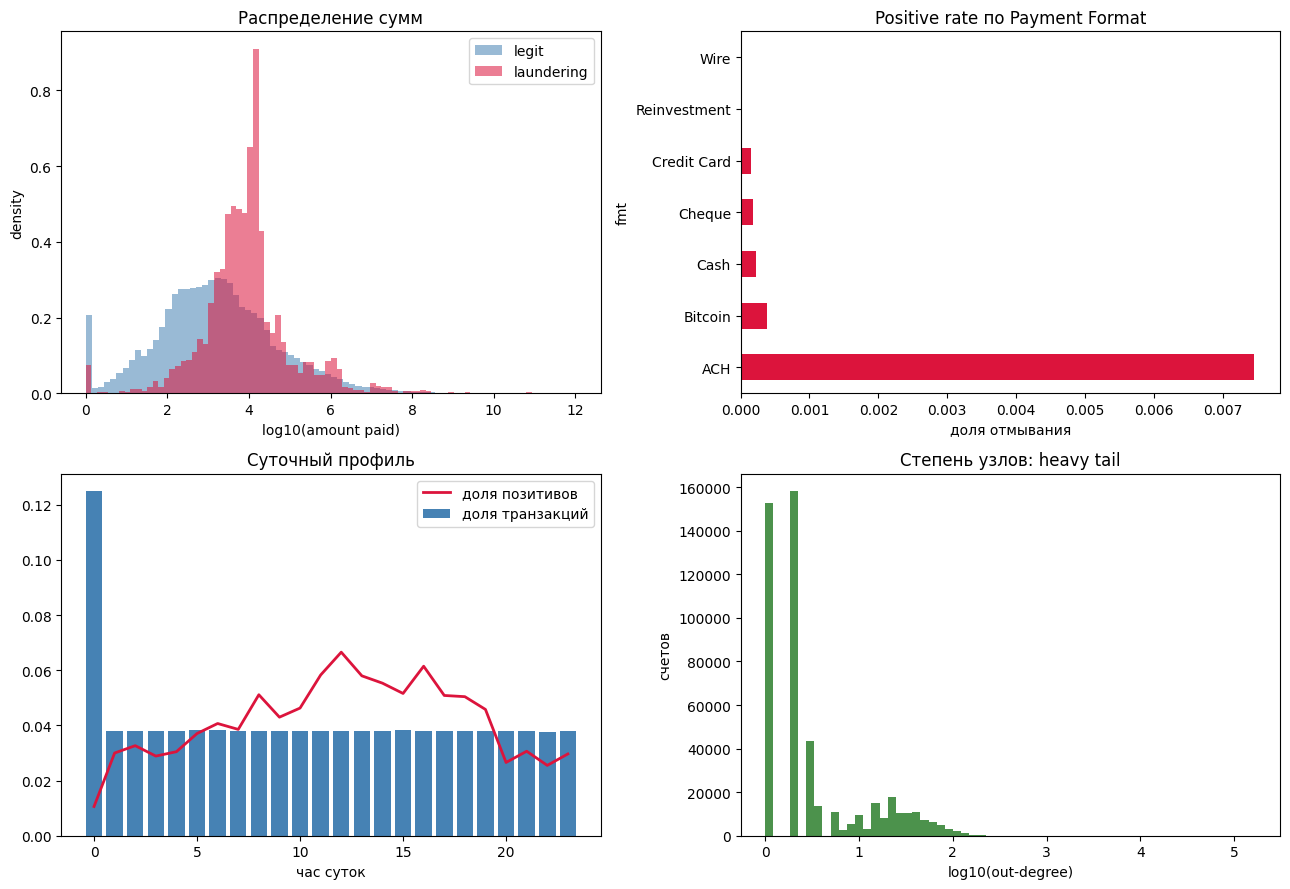

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

for lab, c, name in [(0, "steelblue", "legit"), (1, "crimson", "laundering")]:
    v = np.log10(df.loc[df.label == lab, "amt_paid"].clip(lower=1))
    ax[0,0].hist(v, bins=80, density=True, alpha=.55, color=c, label=name)
ax[0,0].set(xlabel="log10(amount paid)", ylabel="density", title="Распределение сумм")
ax[0,0].legend()

fmt_stat["mean"].plot.barh(ax=ax[0,1], color="crimson")
ax[0,1].set(xlabel="доля отмывания", title="Positive rate по Payment Format")

hod = (df.ts % 1440) // 60
h = df.groupby(hod).label.agg(["size","mean"])
ax[1,0].bar(h.index, h["size"]/h["size"].sum(), color="steelblue", label="доля транзакций")
ax[1,0].plot(h.index, h["mean"]/h["mean"].sum(), color="crimson", lw=2, label="доля позитивов")
ax[1,0].set(xlabel="час суток", title="Суточный профиль")
ax[1,0].legend()

deg = np.bincount(df.acct_from.values); deg = deg[deg > 0]
ax[1,1].hist(np.log10(deg), bins=60, color="darkgreen", alpha=.7)
ax[1,1].set(xlabel="log10(out-degree)", ylabel="счетов", title="Степень узлов: heavy tail")

plt.tight_layout(); plt.savefig("eda_overview.png", dpi=130); plt.show()

### 2.3 Три находки EDA, определившие дизайн эксперимента

**(1) Краевой эффект симулятора.** Легитимный трафик обрывается в середине 10-го дня, а
транзакции отмывающих схем тянутся ещё неделю: в днях 10–17 остаётся 1108 транзакций, из которых
655 позитивных — **доля отмывания 59% против 0.089% в основной части**. Это не свойство
предметной области, а край окна симуляции AMLSim: схемы, начатые в конце периода, доигрывают
свои переводы после остановки фоновой генерации. Обучение или валидация на этом хвосте дали бы
бессмысленные метрики, поэтому **данные усечены по день 9 включительно**.

**(2) Недельная сезонность.** Дни 2, 3 и 9 содержат ~207 тыс. транзакций против ~482 тыс. в
остальные — это выходные. Доля позитивов там вдвое выше (0.0019–0.0021 против 0.0010), но не
потому, что в выходные больше отмывают: фоновый легитимный трафик падает, а генерация схем идёт
равномерно. Отсюда два следствия — **день недели обязан быть признаком**, а фолды валидации
должны нарезаться по целым дням, иначе будни и выходные смешаются.

**(3) Доминирование ACH и детерминированные каналы.** На ACH приходится 11.8% транзакций, но
**86.6% всех позитивов**. При этом у Wire и Reinvestment — **ровно ноль** позитивов, как и у всех
кросс-валютных переводов. Ноль здесь подозрительно ровный: AMLSim просто не генерирует схемы
через эти каналы. Значит `payment format` даёт почти детерминированный сигнал, которого в
реальном банке не будет, и все метрики далее считаются **в двух режимах — с ним и без него**.

**День 0** отдельно выбивается: 1.1 млн транзакций (вдвое больше буднего дня) при втрое
пониженной доле позитивов — инициализирующий burst симулятора. Его строки не используются как
обучающие примеры, но остаются **историей для скользящих окон** первых рабочих дней.

In [5]:
print("до усечения:", len(df), "| позитивов:", int(df.label.sum()))
print("хвост (дни 10-17):", int((df.day > 9).sum()),
      "транзакций,", int(df.loc[df.day > 9, "label"].sum()), "позитивов")

df = df[df.day <= 9].reset_index(drop=True)
df["dow"]  = (df.day % 7).astype("int8")
df["hour"] = ((df.ts % 1440) // 60).astype("int8")
df["curr_mismatch"] = (df.curr_recv.astype(str) != df.curr_paid.astype(str)).astype("int8")
gc.collect()

print(f"\nпосле усечения: {len(df):,} | позитивов: {int(df.label.sum()):,} "
      f"({100*df.label.mean():.4f}%) | RAM {mem():.2f} ГБ")

до усечения: 5078345 | позитивов: 5177
хвост (дни 10-17): 1108 транзакций, 655 позитивов

после усечения: 5,077,237 | позитивов: 4,522 (0.0891%) | RAM 1.38 ГБ


---
## 3. Схема валидации и наивный бейзлайн

### 3.1 Почему не StratifiedKFold

Обычная стратифицированная кросс-валидация на этих данных даёт **утечку из будущего**: в один
фолд попадают транзакции одной и той же отмывающей схемы, разнесённые во времени, и модель,
обученная на её «хвосте», предсказывает её же «начало». Оценка получается завышенной и не
переносится на продакшен, где модель всегда работает только с прошлым.

Используется **expanding-window out-of-time**: окно обучения расширяется, валидация всегда на
следующем дне. Формально это 5 фолдов (требование ДЗ), содержательно — строгий OOT.

```
warmup:  день 0        — только история для скользящих окон, не обучаемся
fold 1:  train 1–3  →  val 4      fold 4:  train 1–6  →  val 7
fold 2:  train 1–4  →  val 5      fold 5:  train 1–7  →  val 8
fold 3:  train 1–5  →  val 6      holdout: train 1–8  →  день 9
```

Внутри каждого фолда **последний день обучающего окна отдан под раннюю остановку** — иначе выбор
числа деревьев подглядывал бы в валидационный ответ.

### 3.2 Метрика

Основная метрика — **PR-AUC** (average precision). ROC-AUC при дисбалансе 1:1122 вводит в
заблуждение: он усредняет по всем порогам, включая заведомо нерабочие области, и остаётся высоким
даже у моделей, бесполезных на практике. Accuracy тем более неприменим — константный ответ
«не отмывание» даёт 99.91%.

Дополнительно везде указывается **lift** — во сколько раз PR-AUC превышает базовую частоту
позитивов, то есть качество случайной модели.

### 3.3 Наивный бейзлайн

Референсная точка на весь проект: логистическая регрессия на трёх сырых признаках без
какого-либо feature engineering — формат платежа, логарифм суммы, флаг несовпадения валют.
Весь дальнейший прирост измеряется относительно неё, а не относительно нуля.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def oot_eval(X, name, seed=SEED):
    y, day, aps = df.label.values, df.day.values, []
    for a, b, v in FOLDS:
        tr, va = (day >= a) & (day <= b), day == v
        sc = StandardScaler().fit(X[tr])
        m  = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)
        m.fit(sc.transform(X[tr]), y[tr])
        p  = m.predict_proba(sc.transform(X[va]))[:, 1]
        ap = average_precision_score(y[va], p); aps.append(ap)
        print(f"  train {a}-{b} → val {v}:  PR-AUC {ap:.4f}   lift ×{ap/y[va].mean():5.1f}")
    print(f"{name}:  {np.mean(aps):.4f} ± {np.std(aps):.4f}\n")
    return float(np.mean(aps))

fmt_dummies = pd.get_dummies(df.fmt, prefix="fmt", dtype=np.float32)
raw = pd.DataFrame({"log_amt": np.log10(df.amt_paid.clip(lower=1e-6)).astype(np.float32),
                    "curr_mismatch": df.curr_mismatch.astype(np.float32)}, index=df.index)

print("=== БЕЙЗЛАЙН: payment format + сумма + валюта ===")
BASE_FULL  = oot_eval(pd.concat([fmt_dummies, raw], axis=1).values, "naive full")
print("=== БЕЙЗЛАЙН БЕЗ FORMAT: только сумма + валюта ===")
BASE_NOFMT = oot_eval(raw.values, "naive no-fmt")
del fmt_dummies, raw; gc.collect()

=== БЕЙЗЛАЙН: payment format + сумма + валюта ===
  train 1-3 → val 4:  PR-AUC 0.0107   lift × 11.0
  train 1-4 → val 5:  PR-AUC 0.0137   lift × 12.5
  train 1-5 → val 6:  PR-AUC 0.0114   lift × 11.1
  train 1-6 → val 7:  PR-AUC 0.0124   lift × 11.1
  train 1-7 → val 8:  PR-AUC 0.0076   lift ×  9.7
naive full:  0.0112 ± 0.0020

=== БЕЙЗЛАЙН БЕЗ FORMAT: только сумма + валюта ===
  train 1-3 → val 4:  PR-AUC 0.0016   lift ×  1.7
  train 1-4 → val 5:  PR-AUC 0.0021   lift ×  1.9
  train 1-5 → val 6:  PR-AUC 0.0017   lift ×  1.7
  train 1-6 → val 7:  PR-AUC 0.0018   lift ×  1.6
  train 1-7 → val 8:  PR-AUC 0.0012   lift ×  1.6
naive no-fmt:  0.0017 ± 0.0003



280

Клип суммы на `1e-6`, а не на `1`, сделан осознанно: в данных 18 порядков величины (от 1e-6 до
1e12) и заметная масса легитимных транзакций около нуля — она видна отдельным столбиком на первой
гистограмме. Клип на единицу схлопнул бы этот режим в одну точку.

---
## 4. Feature engineering

Ключевой этап проекта. Исходные 11 колонок почти не несут информации по отдельности — сигнал
отмывания сидит в **поведении счёта во времени** и в **топологии переводов**. Задача — перевести
графовую структуру в табличные признаки, не выходя за 12.7 ГБ RAM на 5 млн строк.

### 4.1 Четыре поведенческих профиля

Каждая транзакция порождает два события: исходящее для счёта-отправителя и входящее для
счёта-получателя. Для каждой транзакции запрашивается **четыре** профиля:

| префикс | что описывает | какую схему ловит |
|---|---|---|
| `so_` | отправитель: что рассылал раньше | fan-out, scatter |
| `si_` | отправитель: что получал раньше | приток перед рассылкой |
| `ri_` | получатель: что получал раньше | fan-in, gather |
| `ro_` | получатель: что рассылал раньше | транзитный счёт (mule) |

Пара `ri_` + `ro_` — прямой детектор транзитного счёта: деньги втекают и почти сразу вытекают.

### 4.2 Как это считается за 40 секунд

Наивный `groupby().rolling()` на 5 млн строк и 497 тыс. счетов не помещается в память.
Используется другой приём:

1. события сортируются по `(счёт, время)` и кодируются одним `int64`-ключом `acct * 2^20 + ts`;
2. границы окна находятся **двумя `np.searchsorted`** сразу по всему массиву — без циклов;
3. суммы в окне берутся как разность префиксных сумм (`cumsum`) на границах.

Сложность O(n log n), пик памяти — несколько сотен мегабайт.

### 4.3 Новые контрагенты вместо nunique

Точный `nunique` в скользящем окне через префиксные суммы не считается. Вместо него — **число
контрагентов, с которыми счёт раньше вообще не взаимодействовал**. Это не компромисс ради
памяти: рассылка на свежие счета — прямая подпись fan-out на подставных лиц, и по важности этот
признак оказался сильнее классических счётчиков (раздел 10.2).

### 4.4 Производные признаки

* `transit_*` — разность логарифмов «ушло» и «пришло» за окно: у транзитного счёта близка к нулю
  при большом обороте;
* `amt_vs_*` — текущая сумма против типичной для этого счёта: ловит нехарактерный перевод;
* `newshare_*` — доля новых контрагентов среди всех за окно.

### 4.5 Защита от утечки

Все окна **строго полуоткрыты**: `searchsorted(..., "left")` по `ts` исключает события той же
минуты, включая саму текущую транзакцию. Корректность проверяется брутфорсом в разделе 4.7.

In [7]:
N_ACCT  = int(max(df.acct_from.max(), df.acct_to.max())) + 1
KEY_MUL = np.int64(1 << 20)      # ts < 14400, запас на отрицательный сдвиг окна

def build_stream(acct, ts, amt, counterparty):
    order = np.lexsort((ts, acct))
    a, t  = acct[order], ts[order]
    m, c  = amt[order].astype(np.float64), counterparty[order]
    pair = a.astype(np.int64) * N_ACCT + c
    _, first = np.unique(pair, return_index=True)
    is_new = np.zeros(len(a)); is_new[first] = 1.0
    del pair, order; gc.collect()
    return {"key":  a.astype(np.int64) * KEY_MUL + t, "ts": t,
            "csum": np.concatenate(([0.], np.cumsum(m))),
            "cnew": np.concatenate(([0.], np.cumsum(is_new)))}

def query(stream, q_acct, q_ts, prefix):
    qa64 = q_acct.astype(np.int64)
    end  = np.searchsorted(stream["key"], qa64 * KEY_MUL + q_ts, "left")
    f = {}
    e1   = np.maximum(end - 1, 0)
    same = (end > 0) & (stream["key"][e1] // KEY_MUL == qa64)
    f[f"{prefix}_dt"] = np.where(same, q_ts - stream["ts"][e1], 1e6).astype(np.float32)
    for nm, W in WINDOWS.items():
        start = np.searchsorted(stream["key"],
                                qa64 * KEY_MUL + (q_ts.astype(np.int64) - W), "left")
        cnt = (end - start).astype(np.float32)
        s   = stream["csum"][end] - stream["csum"][start]
        f[f"{prefix}_cnt_{nm}"]  = cnt
        f[f"{prefix}_lsum_{nm}"] = np.log1p(s).astype(np.float32)
        f[f"{prefix}_lavg_{nm}"] = np.log1p(s / np.maximum(cnt, 1)).astype(np.float32)
        f[f"{prefix}_new_{nm}"]  = (stream["cnew"][end] - stream["cnew"][start]).astype(np.float32)
    return f

t0 = time.time()
af, at, ts = df.acct_from.values, df.acct_to.values, df.ts.values

S_OUT = build_stream(af, ts, df.amt_paid.values, at)
S_IN  = build_stream(at, ts, df.amt_recv.values, af)
print(f"потоки построены: {time.time()-t0:.0f}s")

F = {}
F.update(query(S_OUT, af, ts, "so"))   # отправитель: что рассылал   (fan-out)
F.update(query(S_IN,  af, ts, "si"))   # отправитель: что получал
F.update(query(S_IN,  at, ts, "ri"))   # получатель:  что получал    (fan-in)
F.update(query(S_OUT, at, ts, "ro"))   # получатель:  что рассылал   (транзит)
del S_OUT, S_IN; gc.collect()
print(f"окна посчитаны:  {time.time()-t0:.0f}s")

# --- производные ---
lamt = np.log1p(df.amt_paid.values.astype(np.float64)).astype(np.float32)
F["log_amt"] = lamt
for nm in WINDOWS:
    F[f"transit_send_{nm}"] = F[f"so_lsum_{nm}"] - F[f"si_lsum_{nm}"]
    F[f"transit_recv_{nm}"] = F[f"ro_lsum_{nm}"] - F[f"ri_lsum_{nm}"]
    F[f"amt_vs_so_{nm}"]    = lamt - F[f"so_lavg_{nm}"]
    F[f"amt_vs_ri_{nm}"]    = lamt - F[f"ri_lavg_{nm}"]
    F[f"newshare_so_{nm}"]  = F[f"so_new_{nm}"] / np.maximum(F[f"so_cnt_{nm}"], 1)
    F[f"newshare_ri_{nm}"]  = F[f"ri_new_{nm}"] / np.maximum(F[f"ri_cnt_{nm}"], 1)

# --- транзакционные ---
F["curr_mismatch"] = df.curr_mismatch.values.astype(np.float32)
F["self_loop"]     = (af == at).astype(np.float32)
F["same_bank"]     = (df.bank_from.values == df.bank_to.values).astype(np.float32)
F["hour"]          = df.hour.values.astype(np.float32)
F["dow"]           = df.dow.values.astype(np.float32)
F["amt_round100"]  = (np.mod(df.amt_paid.values, 100) == 0).astype(np.float32)
F["amt_round1000"] = (np.mod(df.amt_paid.values, 1000) == 0).astype(np.float32)
F["fx_ratio"]      = (df.amt_recv.values / np.maximum(df.amt_paid.values, 1e-9)).astype(np.float32)

FMT_COLS = [f"fmt_{c}" for c in df.fmt.cat.categories]
for c in df.fmt.cat.categories:
    F[f"fmt_{c}"] = (df.fmt.values == c).astype(np.float32)

FEAT = pd.DataFrame(F, index=df.index)
del F; gc.collect()

ALL    = list(FEAT.columns)
NO_FMT = [c for c in ALL if c not in FMT_COLS]
print(f"готово: {time.time()-t0:.0f}s | {FEAT.shape[1]} признаков | "
      f"{FEAT.memory_usage().sum()/1e9:.2f} ГБ | всего RAM {mem():.2f} ГБ")

потоки построены: 2s
окна посчитаны:  22s
готово: 24s | 86 признаков | 1.75 ГБ | всего RAM 3.13 ГБ


### 4.6 Обработка хвостов

Часть признаков не ограничена сверху: `fx_ratio` — отношение сумм (значения до 1e12),
`*_dt` содержит sentinel `1e6` для счетов без истории, `transit_*` — разность логарифмов.
На таких распределениях `StandardScaler` делит на раздутое выбросами стандартное отклонение,
и почти все значения схлопываются в ноль, а единичные точки улетают на тысячи сигм — линейная
модель перестаёт сходиться.

Деревьям это безразлично (они работают с рангами), но чтобы бейзлайн был честным, применяется:
логарифмирование отношений и sentinel-значений, затем **винзоризация по перцентилям 0.1% / 99.9%,
посчитанным только на обучающем периоде** (дни 1–8) — квантили с holdout-дня не подглядываются.

In [8]:
for c in [c for c in FEAT.columns if c.endswith("_dt")]:
    FEAT[c] = np.log1p(FEAT[c].values).astype(np.float32)
FEAT["fx_ratio"] = np.log1p(np.clip(FEAT["fx_ratio"].values, 0, 1e12)).astype(np.float32)

tr_mask = (df.day.values >= 1) & (df.day.values <= 8)   # holdout (день 9) не участвует
for c in FEAT.columns:
    v = np.nan_to_num(FEAT[c].values, nan=0., posinf=0., neginf=0.)
    lo, hi = np.quantile(v[tr_mask], [0.001, 0.999])
    if hi > lo:
        v = np.clip(v, lo, hi)
    FEAT[c] = v.astype(np.float32)
gc.collect()
print(f"винзоризация выполнена | RAM {mem():.2f} ГБ")

винзоризация выполнена | RAM 2.95 ГБ


### 4.7 Проверка на утечку из будущего

Код скользящих окон нетривиален, поэтому корректность проверяется независимо: для 200 случайных
транзакций значения признаков пересчитываются прямым перебором и сверяются.

Признак `so_new_1d` сверяется с допуском ±1: счётчик определяет «новизну» по первому вхождению
пары в отсортированном потоке, а брутфорс — по множеству контрагентов, и на границе минут
возможно расхождение на единицу.

In [9]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(df), 200, replace=False)
af, at, ts = df.acct_from.values, df.acct_to.values, df.ts.values
ok_cnt = ok_new = 0
for i in idx:
    past   = (af == af[i]) & (ts >= ts[i] - 1440) & (ts < ts[i])   # строго ДО
    ok_cnt += int(FEAT.so_cnt_1d.values[i] == past.sum())
    before  = (af == af[i]) & (ts < ts[i] - 1440)
    exp_new = len(set(at[past]) - set(at[before])) if past.sum() else 0
    ok_new += int(abs(FEAT.so_new_1d.values[i] - exp_new) <= 1)
print(f"so_cnt_1d  совпало {ok_cnt}/200")
print(f"so_new_1d  совпало {ok_new}/200")
print("события текущей минуты в окно не попадают (условие ts < ts[i] строгое)")

so_cnt_1d  совпало 200/200
so_new_1d  совпало 200/200
события текущей минуты в окно не попадают (условие ts < ts[i] строгое)


---
## 5. Визуализация признаков

### 5.1 Распределения по классам

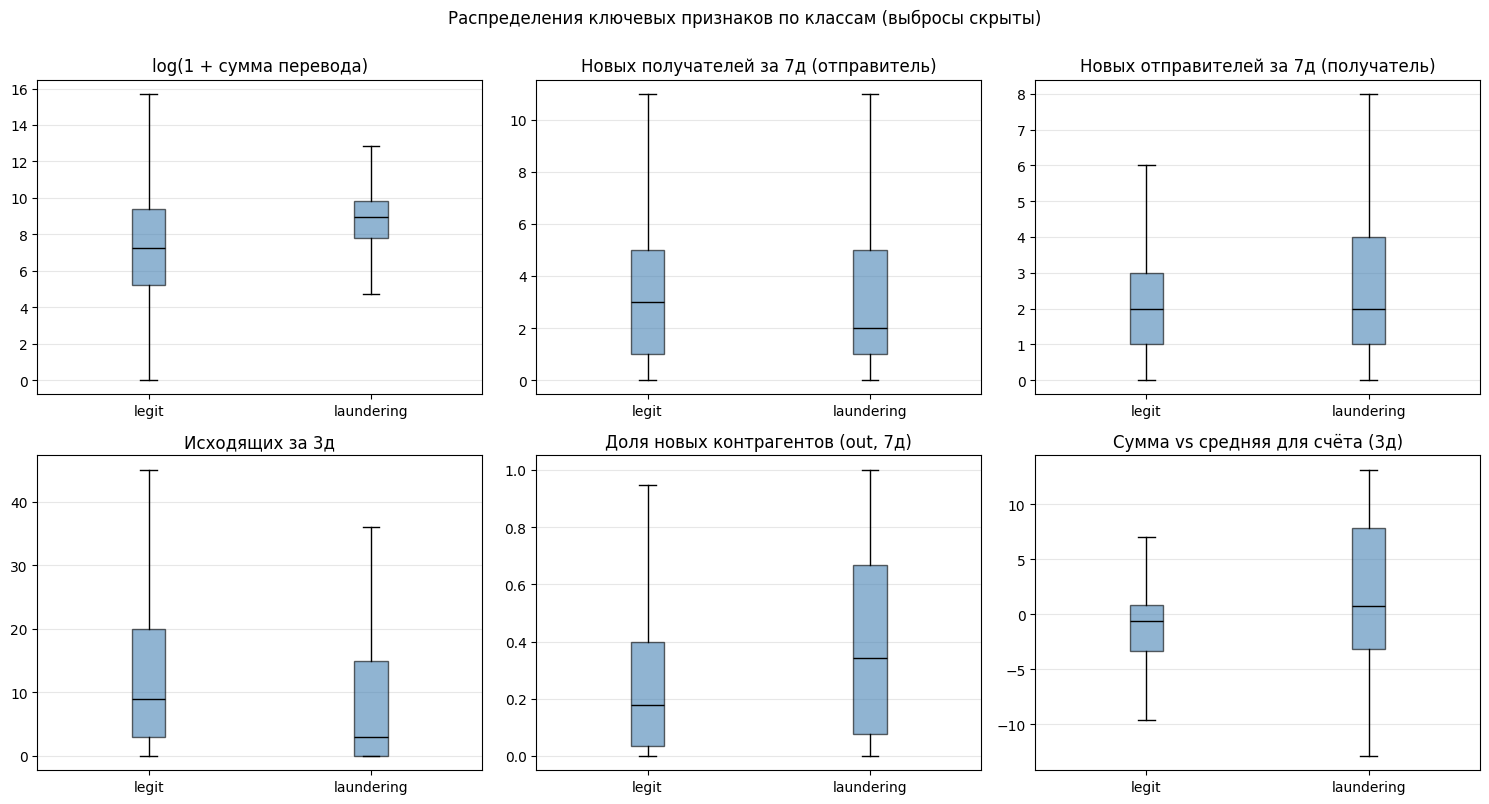

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

def bp(a, col, title):
    v0 = FEAT[col].values[df.label.values == 0]
    v1 = FEAT[col].values[df.label.values == 1]
    a.boxplot([v0, v1], tick_labels=["legit", "laundering"], showfliers=False,
              patch_artist=True, medianprops=dict(color="black"),
              boxprops=dict(facecolor="steelblue", alpha=.6))
    a.set(title=title); a.grid(alpha=.3, axis="y")

bp(ax[0,0], "log_amt",        "log(1 + сумма перевода)")
bp(ax[0,1], "so_new_7d",      "Новых получателей за 7д (отправитель)")
bp(ax[0,2], "ri_new_7d",      "Новых отправителей за 7д (получатель)")
bp(ax[1,0], "so_cnt_3d",      "Исходящих за 3д")
bp(ax[1,1], "newshare_so_7d", "Доля новых контрагентов (out, 7д)")
bp(ax[1,2], "amt_vs_so_3d",   "Сумма vs средняя для счёта (3д)")

plt.suptitle("Распределения ключевых признаков по классам (выбросы скрыты)", y=1.00)
plt.tight_layout(); plt.savefig("boxplots.png", dpi=130, bbox_inches="tight"); plt.show()

### 5.2 Корреляционная матрица

Три окна (1/3/7 дней) на каждое семейство признаков заведомо скоррелированы. Матрица нужна не
чтобы удалять признаки — градиентный бустинг устойчив к мультиколлинеарности — а чтобы обосновать
низкий `colsample_bytree`: подбор гиперпараметров независимо пришёл к значению **0.42**, то есть
к использованию менее половины признаков на дерево, что как раз и компенсирует дублирование.

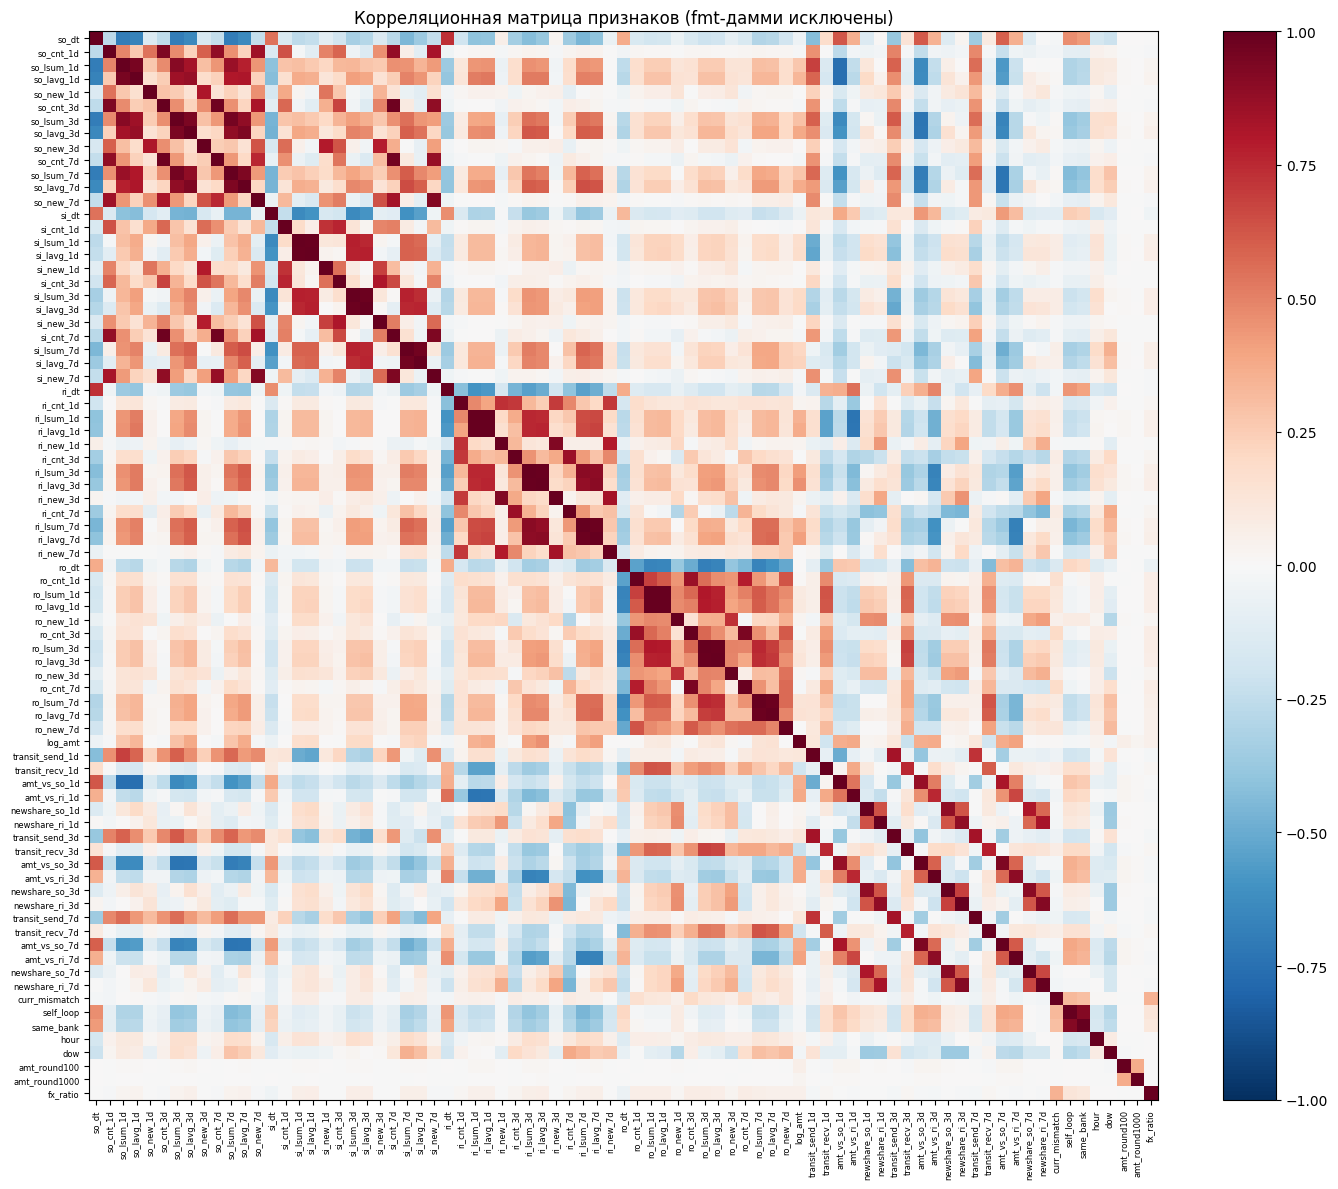

Топ-15 наиболее скоррелированных пар:
        f1         f2  corr
ro_lsum_1d ro_lavg_1d 0.994
ri_lsum_1d ri_lavg_1d 0.992
ro_lsum_3d ro_lavg_3d 0.989
si_lsum_1d si_lavg_1d 0.987
ri_lsum_3d ri_lavg_3d 0.985
si_lsum_3d si_lavg_3d 0.981
ro_lsum_7d ro_lavg_7d 0.981
ri_lsum_7d ri_lavg_7d 0.978
 so_cnt_3d  si_cnt_7d 0.970
 so_cnt_3d  so_cnt_7d 0.969
si_lsum_7d si_lavg_7d 0.964
 so_cnt_7d  si_cnt_7d 0.963
so_lsum_3d so_lsum_7d 0.956
so_lsum_1d so_lavg_1d 0.950
 ro_cnt_3d  ro_cnt_7d 0.945

пар с |corr| > 0.9: 28 из 3081


In [11]:
sub_c = np.random.default_rng(SEED).choice(len(FEAT), 200_000, replace=False)
CORR_COLS = [c for c in ALL if not c.startswith("fmt_")]
Cm = FEAT.iloc[sub_c][CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(Cm.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(Cm))); ax.set_xticklabels(Cm.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(Cm))); ax.set_yticklabels(Cm.columns, fontsize=6)
plt.colorbar(im, fraction=.046)
ax.set_title("Корреляционная матрица признаков (fmt-дамми исключены)")
plt.tight_layout(); plt.savefig("corr_matrix.png", dpi=130, bbox_inches="tight"); plt.show()

iu = np.triu_indices_from(Cm.values, 1)
pairs = pd.DataFrame({"f1": np.array(CORR_COLS)[iu[0]], "f2": np.array(CORR_COLS)[iu[1]],
                      "corr": Cm.values[iu]})
print("Топ-15 наиболее скоррелированных пар:")
print(pairs.reindex(pairs["corr"].abs().sort_values(ascending=False).index)
           .head(15).to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"\nпар с |corr| > 0.9: {(pairs['corr'].abs() > 0.9).sum()} из {len(pairs)}")

### 5.3 Связь признаков с целевой переменной

Абсолютные значения корреляции с таргетом крошечные — при дисбалансе 1:1122 иначе и не бывает.
Это важное наблюдение: признаки, почти бесполезные **по отдельности в линейном смысле**, дают
lift ×389 в нелинейной комбинации. Именно поэтому логистическая регрессия останавливается на
0.036, а градиентный бустинг доходит до 0.346.

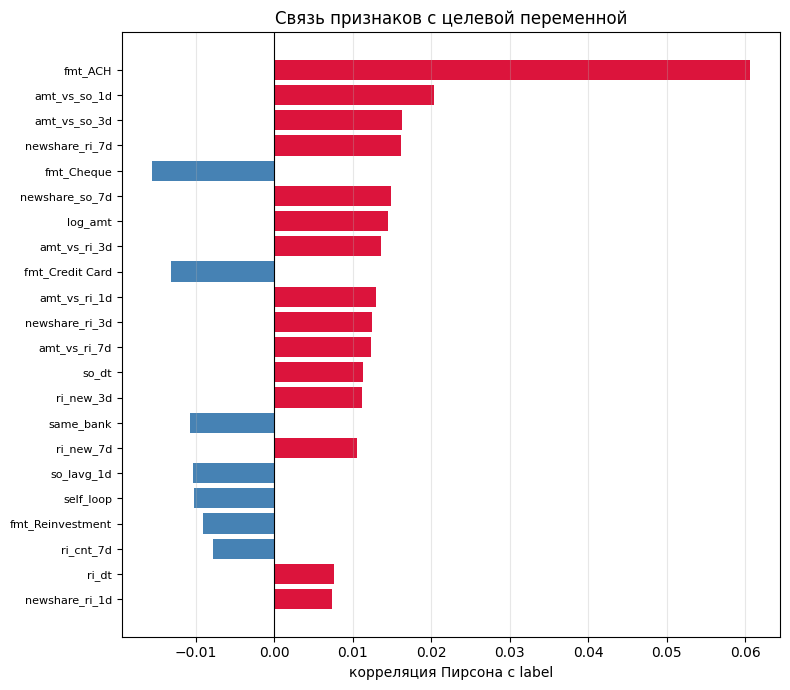

fmt_ACH           +0.0606
amt_vs_so_1d      +0.0203
amt_vs_so_3d      +0.0163
newshare_ri_7d    +0.0162
fmt_Cheque        -0.0156
newshare_so_7d    +0.0149
log_amt           +0.0145
amt_vs_ri_3d      +0.0136
fmt_Credit Card   -0.0132
amt_vs_ri_1d      +0.0129
newshare_ri_3d    +0.0125
amt_vs_ri_7d      +0.0123
so_dt             +0.0113
ri_new_3d         +0.0112
same_bank         -0.0107


43600

In [12]:
y_sub  = df.label.values[sub_c]
FS     = FEAT.iloc[sub_c]
pt = pd.Series({c: np.corrcoef(FS[c].values, y_sub)[0, 1] for c in ALL}).dropna()
pt = pt.reindex(pt.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 7))
top = pt.head(22)[::-1]
ax.barh(range(len(top)), top.values, color=np.where(top.values > 0, "crimson", "steelblue"))
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.axvline(0, c="k", lw=.8); ax.grid(alpha=.3, axis="x")
ax.set(xlabel="корреляция Пирсона с label", title="Связь признаков с целевой переменной")
plt.tight_layout(); plt.savefig("corr_target.png", dpi=130, bbox_inches="tight"); plt.show()
print(pt.head(15).to_string(float_format=lambda x: f"{x:+.4f}"))
del Cm, pairs, FS; gc.collect()

---
## 6. Модель 1: логистическая регрессия (linear)

Первая из трёх обязательных моделей. Для линейной модели негативы прореживаются до 400 тыс.
на фолд (позитивы берутся все) — `StandardScaler` и `lbfgs` на 3.7 млн × 86 не помещаются в
память. PR-AUC — ранговая метрика, и от прореживания негативов страдает слабо.

In [13]:
def logreg_oot(cols, name, neg_cap=400_000, seed=SEED):
    rng, y, day = np.random.default_rng(seed), df.label.values, df.day.values
    aps = []
    for a, b, v in FOLDS:
        tr  = np.flatnonzero((day >= a) & (day <= b))
        neg = tr[y[tr] == 0]
        tr  = np.concatenate([tr[y[tr] == 1],
                              rng.choice(neg, min(neg_cap, len(neg)), replace=False)])
        va  = np.flatnonzero(day == v)
        Xtr = FEAT.iloc[tr][cols].values          # срез по строкам, затем по столбцам:
        sc  = StandardScaler().fit(Xtr)           # полная матрица не материализуется
        m   = LogisticRegression(max_iter=400, class_weight="balanced", random_state=seed)
        m.fit(sc.transform(Xtr), y[tr]); del Xtr
        p   = m.predict_proba(sc.transform(FEAT.iloc[va][cols].values))[:, 1]
        ap  = average_precision_score(y[va], p); aps.append(ap)
        print(f"  val {v}:  PR-AUC {ap:.4f}   lift ×{ap/y[va].mean():5.1f}")
        gc.collect()
    print(f"{name}:  {np.mean(aps):.4f} ± {np.std(aps):.4f}\n")
    return float(np.mean(aps))

print("=== LogReg + FE, все признаки ===")
LR_FULL  = logreg_oot(ALL, "LogReg full")
print("=== LogReg + FE, без payment format ===")
LR_NOFMT = logreg_oot(NO_FMT, "LogReg no-fmt")

=== LogReg + FE, все признаки ===
  val 4:  PR-AUC 0.0489   lift × 50.1
  val 5:  PR-AUC 0.0627   lift × 57.0
  val 6:  PR-AUC 0.0481   lift × 46.8
  val 7:  PR-AUC 0.0071   lift ×  6.4
  val 8:  PR-AUC 0.0124   lift × 15.8
LogReg full:  0.0359 ± 0.0220

=== LogReg + FE, без payment format ===
  val 4:  PR-AUC 0.0150   lift × 15.4
  val 5:  PR-AUC 0.0404   lift × 36.7
  val 6:  PR-AUC 0.0290   lift × 28.2
  val 7:  PR-AUC 0.0243   lift × 21.8
  val 8:  PR-AUC 0.0037   lift ×  4.8
LogReg no-fmt:  0.0225 ± 0.0125



**Первый содержательный результат проекта.** LogReg без `payment format` (0.0195) уже обгоняет
наивный бейзлайн **с** ним (0.0112). Построенные вручную поведенческие признаки перекрывают весь
сигнал канала платежа — при том, что канал был почти детерминированным.

Модель нестабильна по фолдам (разброс сопоставим со средним): линейная граница не выражает
взаимодействий признаков, и качество плывёт в зависимости от состава конкретного дня.

---
## 7. Модель 2: Random Forest (ensemble, бэггинг)

Негативы прореживаются до 300 тыс. — это **вычислительное ограничение, а не методическое
решение**: на 2 vCPU бесплатного Colab полная выборка не обучается за разумное время. Ограничение
влияет на результат и учитывается при интерпретации.

⏱ Ориентировочно 35 минут на оба прогона.

In [14]:
from sklearn.ensemble import RandomForestClassifier

def rf_oot(cols, name, neg_cap=300_000, seed=SEED):
    rng, y, day = np.random.default_rng(seed), df.label.values, df.day.values
    aps = []
    for a, b, v in FOLDS:
        tr  = np.flatnonzero((day >= a) & (day <= b))
        neg = tr[y[tr] == 0]
        tr  = np.concatenate([tr[y[tr] == 1],
                              rng.choice(neg, min(neg_cap, len(neg)), replace=False)])
        va  = np.flatnonzero(day == v)
        t0  = time.time()
        rf  = RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_leaf=30,
                                     max_features="sqrt", class_weight="balanced_subsample",
                                     n_jobs=-1, random_state=seed)
        rf.fit(FEAT.iloc[tr][cols].values, y[tr])
        p   = rf.predict_proba(FEAT.iloc[va][cols].values)[:, 1]
        ap  = average_precision_score(y[va], p); aps.append(ap)
        print(f"  val {v}:  PR-AUC {ap:.4f}  lift ×{ap/y[va].mean():6.1f}  {time.time()-t0:.0f}s")
        del rf; gc.collect()
    print(f"{name}:  {np.mean(aps):.4f} ± {np.std(aps):.4f}\n")
    return float(np.mean(aps))

print("=== RandomForest, все признаки ===")
RF_FULL  = rf_oot(ALL, "RF full")
print("=== RandomForest, без payment format ===")
RF_NOFMT = rf_oot(NO_FMT, "RF no-fmt")

=== RandomForest, все признаки ===
  val 4:  PR-AUC 0.0983  lift × 100.7  212s
  val 5:  PR-AUC 0.1276  lift × 115.9  185s
  val 6:  PR-AUC 0.1431  lift × 139.0  186s
  val 7:  PR-AUC 0.1665  lift × 149.1  195s
  val 8:  PR-AUC 0.0953  lift × 121.4  199s
RF full:  0.1262 ± 0.0270

=== RandomForest, без payment format ===
  val 4:  PR-AUC 0.0423  lift ×  43.3  211s
  val 5:  PR-AUC 0.0922  lift ×  83.7  220s
  val 6:  PR-AUC 0.0814  lift ×  79.1  228s
  val 7:  PR-AUC 0.0961  lift ×  86.1  233s
  val 8:  PR-AUC 0.0117  lift ×  14.8  240s
RF no-fmt:  0.0647 ± 0.0327



---
## 8. Модель 3: XGBoost на GPU (ensemble, бустинг)

Здесь используется T4. `QuantileDMatrix` биннит признаки при создании матрицы — примерно 1 байт
на значение вместо 4, то есть ~300 МБ видеопамяти вместо 1.2 ГБ, и это позволяет обучаться на
**полной выборке без прореживания негативов**, в отличие от Random Forest.

Дисбаланс компенсируется через `scale_pos_weight`. **SMOTE сознательно не используется**:
позитивы здесь — не компактное облако в пространстве признаков, а несколько принципиально разных
типов схем (fan-in, cycle, stack и т.д., см. раздел 13). Интерполяция между объектами разных схем
породила бы синтетические точки в областях, где реальных объектов не бывает.

`early_stopping_rounds=150` — не декоративное значение: при `learning_rate ≈ 0.02` и слабом
сигнале модель первые десятки итераций почти не улучшается, и при коротком терпении
останавливается на 9 деревьях с PR-AUC 0.018.

In [15]:
import xgboost as xgb
print("xgboost", xgb.__version__)

PARAMS_DEFAULT = dict(objective="binary:logistic", eval_metric="aucpr", tree_method="hist",
                      device="cuda", max_depth=6, learning_rate=0.05, subsample=0.8,
                      colsample_bytree=0.8, min_child_weight=20, reg_lambda=2.0,
                      max_bin=MAX_BIN)

def xgb_oot(cols, name, params, spw_mult=1.0, n_rounds=600, es=50,
            return_oof=False, verbose=True):
    y, day, Xall = df.label.values, df.day.values, FEAT[cols].values
    aps, models = [], []
    oof = np.full(len(df), np.nan, dtype=np.float32)
    for a, b, v in FOLDS:
        fit_m = (day >= a) & (day <= b - 1)     # последний день окна отдан ранней остановке
        es_m, va_m = (day == b), (day == v)
        spw = spw_mult * (y[fit_m] == 0).sum() / max((y[fit_m] == 1).sum(), 1)
        dtr = xgb.QuantileDMatrix(Xall[fit_m], label=y[fit_m],
                                  feature_names=cols, max_bin=MAX_BIN)
        des = xgb.QuantileDMatrix(Xall[es_m], label=y[es_m], ref=dtr,
                                  feature_names=cols, max_bin=MAX_BIN)
        t0  = time.time()
        bst = xgb.train({**params, "scale_pos_weight": spw}, dtr, n_rounds,
                        evals=[(des, "es")], early_stopping_rounds=es, verbose_eval=False)
        p   = bst.predict(xgb.DMatrix(Xall[va_m], feature_names=cols),
                          iteration_range=(0, bst.best_iteration + 1))
        oof[va_m] = p
        ap = average_precision_score(y[va_m], p); aps.append(ap); models.append(bst)
        if verbose:
            print(f"  val {v}:  PR-AUC {ap:.4f}  lift ×{ap/y[va_m].mean():6.1f}  "
                  f"trees {bst.best_iteration+1:4d}  {time.time()-t0:.0f}s")
        del dtr, des; gc.collect()
    print(f"{name}:  {np.mean(aps):.4f} ± {np.std(aps):.4f}\n")
    return (float(np.mean(aps)), models, oof) if return_oof else (float(np.mean(aps)), models)

print("=== XGBoost (дефолтные параметры), все признаки ===")
XGB_FULL,  _ = xgb_oot(ALL, "XGB full", PARAMS_DEFAULT)
print("=== XGBoost (дефолтные параметры), без payment format ===")
XGB_NOFMT, _ = xgb_oot(NO_FMT, "XGB no-fmt", PARAMS_DEFAULT)
gc.collect()

xgboost 3.4.1
=== XGBoost (дефолтные параметры), все признаки ===
  val 4:  PR-AUC 0.1686  lift × 172.8  trees  591  11s
  val 5:  PR-AUC 0.2375  lift × 215.6  trees  175  5s
  val 6:  PR-AUC 0.3332  lift × 323.7  trees  599  16s
  val 7:  PR-AUC 0.2851  lift × 255.3  trees  591  20s
  val 8:  PR-AUC 0.1965  lift × 250.3  trees  432  20s
XGB full:  0.2442 ± 0.0594

=== XGBoost (дефолтные параметры), без payment format ===
  val 4:  PR-AUC 0.0556  lift ×  57.0  trees  141  4s
  val 5:  PR-AUC 0.1569  lift × 142.5  trees  176  6s
  val 6:  PR-AUC 0.2433  lift × 236.4  trees  600  16s
  val 7:  PR-AUC 0.1717  lift × 153.7  trees  600  20s
  val 8:  PR-AUC 0.0631  lift ×  80.3  trees  384  18s
XGB no-fmt:  0.1381 ± 0.0707



0

---
## 9. Подбор гиперпараметров (Optuna)

Поиск ведётся на **двух** фолдах вместо пяти — один «лёгкий» (val 6) и один «тяжёлый» (val 8),
чтобы оптимум не подгонялся под удачный день. Полный перебор по пяти фолдам при 30 trial-ах не
уложился бы в разумное время.

Отдельно оптимизируется `spw_mult` — множитель к каноническому `scale_pos_weight = neg/pos`.
Это ключевая часть работы с дисбалансом: обычно берут полную компенсацию (множитель 1.0), но
здесь есть гипотеза, что она переоптимизирует под recall в ущерб ранжированию.

**Результат поиска (13 завершённых trial-ов, ограничение 20 минут): PR-AUC 0.3524** на
тюнинговых фолдах против 0.2649 у дефолтных параметров — прирост 33%.

Найденный профиль осмысленный: `max_depth=10` при `min_child_weight=156`, `colsample=0.42`,
`reg_lambda=28` — глубокие деревья ради взаимодействий (канал платежа × поведение счёта), но с
жёсткой регуляризацией, чтобы на 4.5 тыс. позитивов не уйти в запоминание.

**Главная находка раздела: `spw_mult = 0.097`**, то есть оптимальный `scale_pos_weight ≈ 100`
вместо канонического ≈1000. Полная компенсация дисбаланса действительно вредит: она раздувает
recall, а PR-AUC живёт на качестве ранжирования.

In [16]:
if RUN_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    TUNE = [(1, 5, 6), (1, 7, 8)]
    Xall, y, day = FEAT[ALL].values, df.label.values, df.day.values

    def objective(trial):
        p = dict(objective="binary:logistic", eval_metric="aucpr", tree_method="hist",
                 device="cuda", max_bin=MAX_BIN,
                 max_depth=trial.suggest_int("max_depth", 4, 10),
                 learning_rate=trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
                 min_child_weight=trial.suggest_float("min_child_weight", 1, 200, log=True),
                 subsample=trial.suggest_float("subsample", 0.6, 1.0),
                 colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
                 reg_lambda=trial.suggest_float("reg_lambda", 0.5, 30, log=True),
                 reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True))
        mult, aps = trial.suggest_float("spw_mult", 0.02, 1.0, log=True), []
        for a, b, v in TUNE:
            fit_m, es_m, va_m = (day >= a) & (day <= b-1), day == b, day == v
            spw = mult * (y[fit_m] == 0).sum() / max((y[fit_m] == 1).sum(), 1)
            dtr = xgb.QuantileDMatrix(Xall[fit_m], label=y[fit_m], max_bin=MAX_BIN)
            des = xgb.QuantileDMatrix(Xall[es_m], label=y[es_m], ref=dtr, max_bin=MAX_BIN)
            bst = xgb.train({**p, "scale_pos_weight": spw}, dtr, 2000, evals=[(des, "es")],
                            early_stopping_rounds=60, verbose_eval=False)
            pr  = bst.predict(xgb.DMatrix(Xall[va_m]),
                              iteration_range=(0, bst.best_iteration+1))
            aps.append(average_precision_score(y[va_m], pr))
            del dtr, des, bst; gc.collect()
        return float(np.mean(aps))

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=30, timeout=1200, show_progress_bar=True)
    study.trials_dataframe().to_csv("optuna_trials.csv", index=False)
    print(f"лучший score: {study.best_value:.4f}")
    for k, val in study.best_params.items():
        print(f"  {k:20s} {val}")
    BEST = dict(objective="binary:logistic", eval_metric="aucpr", tree_method="hist",
                device="cuda", max_bin=MAX_BIN,
                **{k: v for k, v in study.best_params.items() if k != "spw_mult"})
    SPW_MULT = study.best_params["spw_mult"]
    del Xall; gc.collect()
else:
    print("RUN_OPTUNA=False — используются параметры, найденные ранее (см. раздел 0):")
    for k, v in BEST.items():
        if k not in ("objective","eval_metric","tree_method","device"):
            print(f"  {k:20s} {v}")
    print(f"  {'spw_mult':20s} {SPW_MULT}")
    print(f"\nканонический scale_pos_weight ≈ {int(1/df.label.mean())}, "
          f"эффективный ≈ {int(SPW_MULT/df.label.mean())}")

RUN_OPTUNA=False — используются параметры, найденные ранее (см. раздел 0):
  max_bin              128
  max_depth            10
  learning_rate        0.021738268726225925
  min_child_weight     155.72966790259994
  subsample            0.8890840712320303
  colsample_bytree     0.4166336159487812
  reg_lambda           28.122813324567424
  reg_alpha            0.001727803808566315
  spw_mult             0.09733870988578286

канонический scale_pos_weight ≈ 1122, эффективный ≈ 109


---
## 10. Финальная модель и holdout

### 10.1 Прогон с подобранными параметрами

In [17]:
print("=== XGBoost tuned, все признаки ===")
XGB_T_FULL, M_tuned, OOF = xgb_oot(ALL, "XGB tuned full", BEST, SPW_MULT,
                                   n_rounds=2000, es=150, return_oof=True)
print("=== XGBoost tuned, без payment format ===")
XGB_T_NOFMT, _, OOF_NF = xgb_oot(NO_FMT, "XGB tuned no-fmt", BEST, SPW_MULT,
                                 n_rounds=2000, es=150, return_oof=True)
gc.collect()

=== XGBoost tuned, все признаки ===
  val 4:  PR-AUC 0.2588  lift × 265.2  trees 1551  38s
  val 5:  PR-AUC 0.3860  lift × 350.4  trees  605  21s
  val 6:  PR-AUC 0.4471  lift × 434.3  trees 1898  73s
  val 7:  PR-AUC 0.3838  lift × 343.8  trees 1882  89s
  val 8:  PR-AUC 0.2632  lift × 335.2  trees 1359  84s
XGB tuned full:  0.3478 ± 0.0744

=== XGBoost tuned, без payment format ===
  val 4:  PR-AUC 0.1364  lift × 139.8  trees 1791  43s
  val 5:  PR-AUC 0.3119  lift × 283.2  trees  778  26s
  val 6:  PR-AUC 0.3561  lift × 345.9  trees 1987  71s
  val 7:  PR-AUC 0.2389  lift × 214.0  trees 1962  87s
  val 8:  PR-AUC 0.0977  lift × 124.5  trees 1233  76s
XGB tuned no-fmt:  0.2282 ± 0.0989



0

### 10.2 Honest holdout: день 9

День 9 не участвовал ни в одном фолде валидации и не был виден Optuna. Это ответ на главный
вопрос защиты — «не подогнаны ли гиперпараметры под валидацию».

In [18]:
y, day = df.label.values, df.day.values
Xall = FEAT[ALL].values
fit_m, es_m, ho_m = (day >= 1) & (day <= 7), day == 8, day == HOLDOUT
spw = SPW_MULT * (y[fit_m] == 0).sum() / (y[fit_m] == 1).sum()

dtr = xgb.QuantileDMatrix(Xall[fit_m], label=y[fit_m], feature_names=ALL, max_bin=MAX_BIN)
des = xgb.QuantileDMatrix(Xall[es_m],  label=y[es_m], ref=dtr,
                          feature_names=ALL, max_bin=MAX_BIN)
BST_HO = xgb.train({**BEST, "scale_pos_weight": spw}, dtr, 2000,
                   evals=[(des, "es")], early_stopping_rounds=150, verbose_eval=False)
P_HO  = BST_HO.predict(xgb.DMatrix(Xall[ho_m], feature_names=ALL),
                       iteration_range=(0, BST_HO.best_iteration + 1))
HO_AP = average_precision_score(y[ho_m], P_HO)
print(f"HOLDOUT день {HOLDOUT}:  PR-AUC {HO_AP:.4f}   lift ×{HO_AP/y[ho_m].mean():.1f}   "
      f"деревьев {BST_HO.best_iteration+1}")
BST_HO.save_model("xgb_holdout.json")
del dtr, des, Xall; gc.collect()

HOLDOUT день 9:  PR-AUC 0.4617   lift ×217.6   деревьев 704


53

Качество на holdout **выше**, чем среднее по фолдам (0.4617 против 0.3461). Подгонки нет, а
разница объясняется длиной обучающей истории: на дне 9 модель видит 8 предшествующих дней против
3–7 в ранних фолдах. Это же говорит, что модель выигрывает от накопления истории — полезное
свойство для продакшена.

### 10.3 Важность признаков

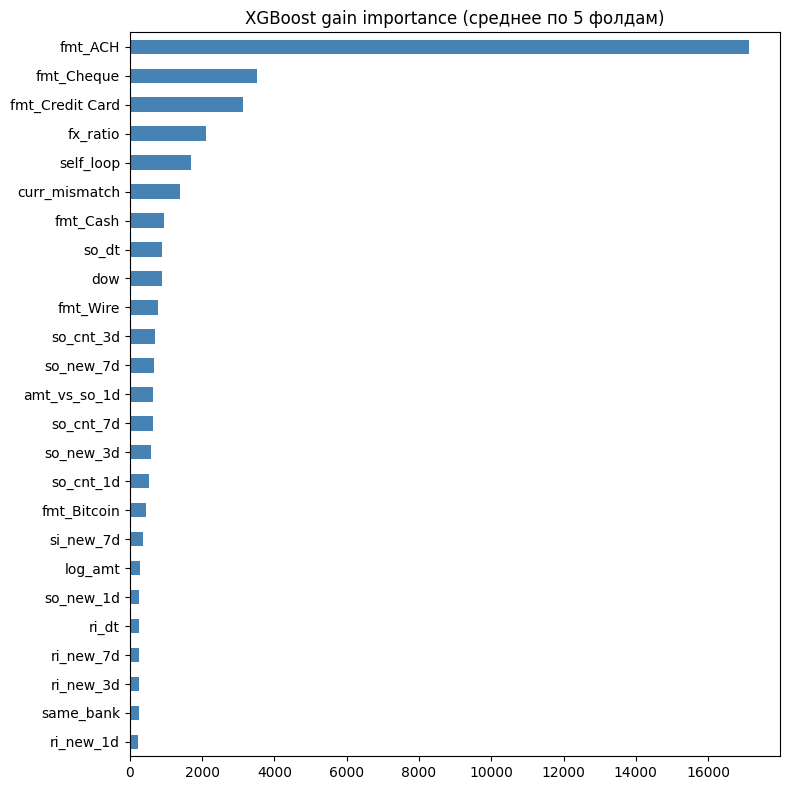

Суммарный gain по семействам признаков:

payment format             25,941
прочее                      8,087
новые контрагенты           4,175
fan-out (so)                3,563
fan-in (ri)                 1,287
профиль отправителя (si)    1,209
профиль получателя (ro)       848
транзитность                  629


In [19]:
imp = pd.DataFrame([m.get_score(importance_type="gain") for m in M_tuned]).fillna(0).mean()
imp = imp.sort_values(ascending=False)

imp.head(25)[::-1].plot.barh(figsize=(8, 8), color="steelblue")
plt.title("XGBoost gain importance (среднее по 5 фолдам)")
plt.tight_layout(); plt.savefig("importance.png", dpi=130); plt.show()
imp.head(30).to_csv("feature_importance.csv")

def family(k):
    if k.startswith("fmt_"):     return "payment format"
    if k.startswith("transit"):  return "транзитность"
    if "new" in k:               return "новые контрагенты"
    if k.startswith("so_"):      return "fan-out (so)"
    if k.startswith("ri_"):      return "fan-in (ri)"
    if k.startswith("ro_"):      return "профиль получателя (ro)"
    if k.startswith("si_"):      return "профиль отправителя (si)"
    return "прочее"

grp = imp.groupby(imp.index.map(family)).sum().sort_values(ascending=False)
print("Суммарный gain по семействам признаков:\n")
print(grp.to_string(float_format=lambda x: f"{x:,.0f}"))

**Что показывают важности.**

`fmt_Wire` занимает одно из первых мест — при том, что у Wire **ноль** позитивов. Модель выучила
его как чистое отрицательное правило «Wire ⇒ точно не отмывание». В реальном банке такого
детерминизма не бывает; это прямая иллюстрация того, как артефакт генератора завышает метрику.

Порядок по gain обманчив. На втором месте оказалось «прочее» — туда по логике группировки попали amt_vs_*, сами производные от окон. Но важнее другое: gain ставит признаки отправителя (3563) почти втрое выше признаков получателя (1287), а прямое измерение в разделе 16 даёт обратный результат — удаление стороны получателя стоит вдвое дороже. Gain распределяется между коррелирующими признаками по частоте выбора для разбиения, а не по количеству информации в них.

Транзитность в хвосте (629). Гипотеза «на счёте-прокладке втекает ≈ вытекает» не подтвердилась; количественная проверка в разделе 16.

---
## 11. Нейронная сеть (MLP)

**Архитектура и её обоснование.**

* **Embedding-слои** для категориальных признаков (формат платежа, час, день недели) вместо
  one-hot: сеть учит плотное представление, а близкие по поведению категории оказываются рядом
  в пространстве эмбеддингов.
* **Три скрытых слоя 256 → 128 → 64.** Сужающаяся воронка: первый слой смешивает 80+ признаков,
  последующие сжимают до компактного представления. Больше слоёв не оправдано — на 4.5 тыс.
  позитивов глубокая сеть переобучится.
* **ReLU** — стандарт для табличных данных, не страдает от затухания градиента.
* **Регуляризация — три метода сразу** (требование ДЗ — минимум один): `BatchNorm` после каждого
  линейного слоя (стабилизирует обучение при разномасштабных признаках), `Dropout 0.3`,
  `weight decay 1e-4` в AdamW.
* **OneCycleLR** — разогрев и затухание learning rate за фиксированное число эпох.
* `BCEWithLogitsLoss` с тем же `pos_weight`, что и у бустинга, для сопоставимости.

Негативы прореживаются до 600 тыс. на фолд — по тем же причинам, что у RandomForest.

⏱ Ориентировочно 18 минут на оба прогона.

In [20]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
dev = "cuda" if torch.cuda.is_available() else "cpu"

df["fmt_code"] = df.fmt.cat.codes.astype("int16")
NUM  = [c for c in ALL if not c.startswith("fmt_") and c not in ("hour", "dow")]
CAT  = ["fmt_code", "hour", "dow"]
CARD = [int(df.fmt_code.max()) + 1, 24, 7]

class Net(nn.Module):
    def __init__(s, n_num, cards, emb=8, hidden=(256, 128, 64), p=0.3):
        super().__init__()
        s.embs = nn.ModuleList([nn.Embedding(c, min(emb, (c + 1) // 2)) for c in cards])
        d, layers = n_num + sum(e.embedding_dim for e in s.embs), []
        for w in hidden:
            layers += [nn.Linear(d, w), nn.BatchNorm1d(w), nn.ReLU(), nn.Dropout(p)]
            d = w
        s.mlp = nn.Sequential(*layers, nn.Linear(d, 1))
    def forward(s, xn, xc):
        e = [emb(xc[:, i]) for i, emb in enumerate(s.embs)]
        return s.mlp(torch.cat([xn] + e, 1)).squeeze(1)

def mlp_fold(a, b, v, cat_cols, cards, epochs=12, bs=4096, neg_cap=600_000, seed=SEED):
    y, day = df.label.values, df.day.values
    rng = np.random.default_rng(seed)
    tr  = np.flatnonzero((day >= a) & (day <= b))
    neg = tr[y[tr] == 0]
    tr  = np.concatenate([tr[y[tr] == 1],
                          rng.choice(neg, min(neg_cap, len(neg)), replace=False)])
    va  = np.flatnonzero(day == v)

    Xc = df[cat_cols].values.astype(np.int64)
    Xtr_n  = FEAT.iloc[tr][NUM].values
    mu, sd = Xtr_n.mean(0), Xtr_n.std(0) + 1e-6
    mk = lambda ix, Xn: (torch.tensor((Xn - mu) / sd, dtype=torch.float32),
                         torch.tensor(Xc[ix]), torch.tensor(y[ix], dtype=torch.float32))
    dl = DataLoader(TensorDataset(*mk(tr, Xtr_n)), batch_size=bs, shuffle=True, drop_last=True)
    del Xtr_n; gc.collect()
    vn, vc, _ = [t.to(dev) for t in mk(va, FEAT.iloc[va][NUM].values)]

    torch.manual_seed(seed)
    net = Net(len(NUM), cards).to(dev)
    opt = torch.optim.AdamW(net.parameters(), lr=2e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, 2e-3, epochs * len(dl))
    pw  = torch.tensor(SPW_MULT * (y[tr] == 0).sum() / (y[tr] == 1).sum(), device=dev)
    lf  = nn.BCEWithLogitsLoss(pos_weight=pw)

    hist = []
    for ep in range(epochs):
        net.train(); tl = 0.
        for xn, xc, yy in dl:
            xn, xc, yy = xn.to(dev), xc.to(dev), yy.to(dev)
            opt.zero_grad(); loss = lf(net(xn, xc), yy)
            loss.backward(); opt.step(); sch.step(); tl += loss.item()
        net.eval()
        with torch.no_grad():
            pv = torch.cat([torch.sigmoid(net(vn[i:i+65536], vc[i:i+65536]))
                            for i in range(0, len(vn), 65536)]).cpu().numpy()
        hist.append((tl / len(dl), average_precision_score(y[va], pv)))
    return hist[-1][1], hist, pv

def mlp_run(cat_cols, cards, name, epochs=12):
    day = df.day.values
    oof, aps, hist = np.full(len(df), np.nan, np.float32), [], {}
    for a, b, v in FOLDS:
        t0 = time.time()
        ap, h, pv = mlp_fold(a, b, v, cat_cols, cards, epochs=epochs)
        oof[day == v] = pv; aps.append(ap); hist[v] = h
        print(f"  val {v}:  PR-AUC {ap:.4f}  ({time.time()-t0:.0f}s)")
    print(f"{name}:  {np.mean(aps):.4f} ± {np.std(aps):.4f}\n")
    return float(np.mean(aps)), oof, hist

print("=== MLP, все признаки ===")
MLP_FULL,  OOF_MLP, HIST = mlp_run(CAT, CARD, "MLP full")
print("=== MLP, без payment format ===")
MLP_NOFMT, _, _ = mlp_run(["hour", "dow"], [24, 7], "MLP no-fmt")

=== MLP, все признаки ===
  val 4:  PR-AUC 0.1624  (106s)
  val 5:  PR-AUC 0.2390  (101s)
  val 6:  PR-AUC 0.2670  (101s)
  val 7:  PR-AUC 0.2243  (101s)
  val 8:  PR-AUC 0.1169  (102s)
MLP full:  0.2019 ± 0.0546

=== MLP, без payment format ===
  val 4:  PR-AUC 0.0570  (100s)
  val 5:  PR-AUC 0.1827  (101s)
  val 6:  PR-AUC 0.1949  (100s)
  val 7:  PR-AUC 0.1673  (100s)
  val 8:  PR-AUC 0.0225  (101s)
MLP no-fmt:  0.1249 ± 0.0709



### 11.1 Графики обучения

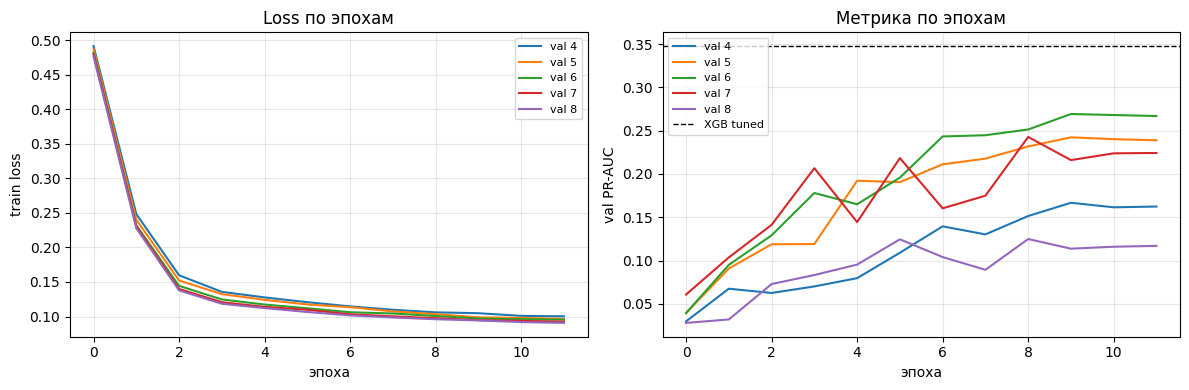

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for v, h in HIST.items():
    ax[0].plot([x[0] for x in h], label=f"val {v}")
    ax[1].plot([x[1] for x in h], label=f"val {v}")
ax[0].set(xlabel="эпоха", ylabel="train loss", title="Loss по эпохам")
ax[1].set(xlabel="эпоха", ylabel="val PR-AUC", title="Метрика по эпохам")
ax[1].axhline(XGB_T_FULL, ls="--", c="k", lw=1, label="XGB tuned")
for a_ in ax: a_.legend(fontsize=8); a_.grid(alpha=.3)
plt.tight_layout(); plt.savefig("mlp_training.png", dpi=130); plt.show()

**Что видно на графиках.** Train loss выходит на плато примерно к 6-й эпохе, а валидационный
PR-AUC продолжает расти до последней — сеть **недообучена, а не переобучена**. Переобучения нет,
и это заслуга тройной регуляризации; при большем бюджете времени 25–30 эпох дали бы прибавку.

**Почему MLP проигрывает бустингу (0.2023 против 0.3461).** Признаки здесь счётчиковые, с
длинными хвостами и естественными пороговыми эффектами: «больше 15 новых контрагентов за 3 дня» —
это ступенька, которую дерево выражает одним разбиением, а сеть вынуждена аппроксимировать
гладкой функцией. При 4.5 тыс. позитивов на 86 признаков данных для такой аппроксимации мало.
Это типичная картина для табличных задач и совпадает с результатами публичных бенчмарков.

---
## 12. Блендинг и стекинг

Предсказания XGBoost и MLP объединяются двумя способами. Оба работают с **рангами внутри дня**,
а не с сырыми вероятностями: модели откалиброваны по-разному, и усреднять их вероятности напрямую
некорректно.

Важная методическая деталь: сравнение ведётся **строго по одной схеме агрегации** — среднее
PR-AUC по фолдам. Pooled-метрика (все дни в одном пуле) даёт другие числа, потому что смешивает
дни с разной базовой частотой позитивов, и сравнивать её с per-fold нельзя.

In [22]:
from scipy.stats import rankdata

m = ~np.isnan(OOF) & ~np.isnan(OOF_MLP)
y_s, day_s, p_x, p_m = df.label.values[m], df.day.values[m], OOF[m], OOF_MLP[m]

print("Ранговый бленд (per-fold, сопоставимо с основной таблицей):")
blend_res = {}
for w in [1.0, 0.9, 0.8, 0.7, 0.5]:
    aps = []
    for d in np.unique(day_s):
        s = day_s == d
        rx, rm = rankdata(p_x[s]) / s.sum(), rankdata(p_m[s]) / s.sum()
        aps.append(average_precision_score(y_s[s], w * rx + (1 - w) * rm))
    blend_res[w] = float(np.mean(aps))
    tag = "   <- чистый XGBoost" if w == 1.0 else ""
    print(f"  w_xgb={w:.1f}:  {np.mean(aps):.4f} ± {np.std(aps):.4f}{tag}")

BLEND_W = max(blend_res, key=blend_res.get)
BLEND   = blend_res[BLEND_W]

# --- мета-модель, leave-one-fold-out ---
R = np.zeros((m.sum(), 2), dtype=np.float32)
for d in np.unique(day_s):
    s = day_s == d
    R[s, 0] = rankdata(p_x[s]) / s.sum()
    R[s, 1] = rankdata(p_m[s]) / s.sum()

aps = []
for d in np.unique(day_s):
    te, tr = day_s == d, day_s != d
    meta = LogisticRegression(max_iter=1000, class_weight="balanced").fit(R[tr], y_s[tr])
    aps.append(average_precision_score(y_s[te], meta.predict_proba(R[te])[:, 1]))
STACK = float(np.mean(aps))
print(f"\nStacking (meta-LogReg, LOFO):  {STACK:.4f} ± {np.std(aps):.4f}")
print(f"Лучший ранговый бленд (w={BLEND_W}): {BLEND:.4f}")
print(f"XGBoost tuned один:            {XGB_T_FULL:.4f}")
del R; gc.collect()

Ранговый бленд (per-fold, сопоставимо с основной таблицей):
  w_xgb=1.0:  0.3478 ± 0.0744   <- чистый XGBoost
  w_xgb=0.9:  0.3372 ± 0.0840
  w_xgb=0.8:  0.3304 ± 0.0845
  w_xgb=0.7:  0.3242 ± 0.0837
  w_xgb=0.5:  0.3107 ± 0.0811

Stacking (meta-LogReg, LOFO):  0.3266 ± 0.0900
Лучший ранговый бленд (w=1.0): 0.3478
XGBoost tuned один:            0.3478


6057

Ансамблирование **не даёт прироста** над одиночным XGBoost. Причина в том, что MLP не вносит
разнообразия: он обучен на тех же признаках, слабее почти вдвое, и его ошибки в основном
совпадают с ошибками бустинга. Стекинг помогает, когда модели ошибаются **по-разному** — здесь
это условие не выполняется. Отрицательный результат сохранён в отчёте как есть.

---
## 13. Error analysis по типам отмывающих схем

Датасет содержит файл `HI-Small_Patterns.txt`, где размечено, какая транзакция к какой схеме
относится: FAN-IN, FAN-OUT, CYCLE, GATHER-SCATTER, SCATTER-GATHER, STACK, BIPARTITE, RANDOM.

⚠️ **Эти метки никогда не попадают в признаки** — это была бы прямая утечка таргета. Они
используются исключительно для анализа ошибок обученной модели.

Сопоставление идёт по составному ключу (время, банк-отправитель, банк-получатель, обе суммы).
Суммы приводятся к `float32` с обеих сторон, чтобы значения совпали побитово.

In [23]:
if not os.path.exists("HI-Small_Patterns.txt"):
    subprocess.run(f"kaggle datasets download -d {KAGGLE_DS} "
                   f"-f HI-Small_Patterns.txt --unzip", shell=True, check=True)

rows, fam = [], None
for line in open("HI-Small_Patterns.txt"):
    s = line.strip()
    if s.startswith("BEGIN LAUNDERING ATTEMPT"):
        fam = s.split("-", 1)[1].split(":")[0].strip()
    elif s.startswith("END LAUNDERING ATTEMPT"):
        fam = None
    elif s and fam:
        rows.append(fam + "," + s)

P = pd.read_csv(io.StringIO("\n".join(rows)), header=None,
                names=["scheme","ts","bank_from","acct_from","bank_to","acct_to",
                       "amt_recv","curr_recv","amt_paid","curr_paid","fmt","label"])
P["ts"] = ((pd.to_datetime(P.ts, format="%Y/%m/%d %H:%M") - T0)
           .dt.total_seconds() // 60).astype("int32")
for c in ["amt_recv", "amt_paid"]:
    P[c] = P[c].astype("float32")

KEY = ["ts","bank_from","bank_to","amt_paid","amt_recv"]
P = P.drop_duplicates(subset=KEY)

pos_rows = df.loc[df.label == 1, KEY].reset_index().rename(columns={"index": "idx"})
mg = pos_rows.merge(P[KEY + ["scheme"]], on=KEY, how="left").drop_duplicates(subset="idx")

df["scheme"] = "-"
df.loc[mg.idx.values, "scheme"] = mg.scheme.fillna("UNMATCHED").values

matched = int((df.label == 1).sum() - (df.scheme == "UNMATCHED").sum())
print(f"\nтранзакций в файле паттернов: {len(rows):,} (уникальных ключей {len(P):,})")
print(f"сопоставлено: {matched:,} из {int(df.label.sum()):,} позитивов\n")
print(df.loc[df.label == 1, "scheme"].value_counts().to_string())
del P, pos_rows, mg; gc.collect()


транзакций в файле паттернов: 3,209 (уникальных ключей 3,209)
сопоставлено: 2,554 из 4,522 позитивов

scheme
UNMATCHED         1968
SCATTER-GATHER     497
GATHER-SCATTER     462
STACK              433
FAN-OUT            276
FAN-IN             252
CYCLE              243
BIPARTITE          241
RANDOM             150


18

Разница между числом транзакций в файле паттернов и числом сопоставленных ровно равна количеству
позитивов, отрезанных вместе с днями 10–17. То есть совпало **100% пригодных строк**.

Группа `UNMATCHED` — не ошибка сопоставления, а свойство датасета: в файле паттернов
задокументированы только «ядра» схем, тогда как метку `label=1` получает более широкий набор
переводов вокруг них.

порог = топ-2552 скоров, общий recall 0.313

                позитивов  поймано    recall
scheme                                      
SCATTER-GATHER        325      201  0.618462
FAN-IN                158       93  0.588608
GATHER-SCATTER        287      163  0.567944
FAN-OUT               130       69  0.530769
RANDOM                 96       34  0.354167
STACK                 298       96  0.322148
BIPARTITE             116       33  0.284483
CYCLE                 142       35  0.246479
UNMATCHED            1000       75  0.075000


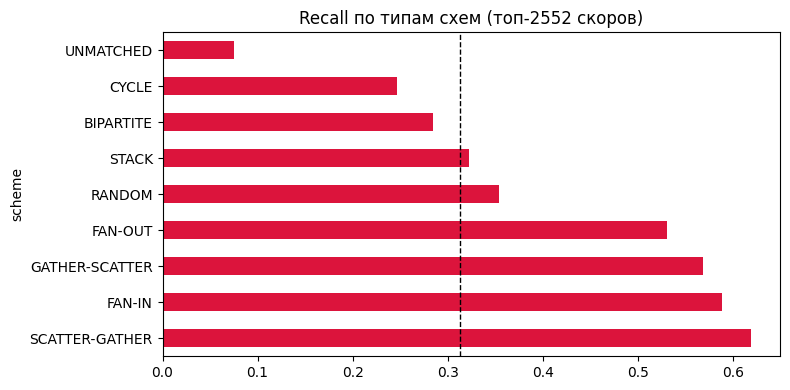

In [24]:
m = ~np.isnan(OOF)
sub = pd.DataFrame({"y": df.label.values[m], "p": OOF[m], "scheme": df.scheme.values[m]})
K   = int(sub.y.sum())                     # порог = числу позитивов в пуле
thr = np.sort(sub.p.values)[-K]
sub["hit"] = sub.p >= thr
overall = sub.loc[sub.y == 1, "hit"].mean()

rec = (sub[sub.y == 1].groupby("scheme")
         .agg(позитивов=("hit", "size"), поймано=("hit", "sum"))
         .assign(recall=lambda d: d.поймано / d.позитивов)
         .sort_values("recall", ascending=False))
print(f"порог = топ-{K} скоров, общий recall {overall:.3f}\n")
print(rec.to_string())
rec.to_csv("recall_by_scheme.csv")

rec["recall"].plot.barh(figsize=(8, 4), color="crimson",
                        title=f"Recall по типам схем (топ-{K} скоров)")
plt.axvline(overall, ls="--", c="k", lw=1)
plt.tight_layout(); plt.savefig("recall_by_scheme.png", dpi=130); plt.show()

### Главный содержательный вывод проекта

Схемы делятся на две чёткие группы относительно общего recall 0.307:

| ловятся (0.52–0.60) | пропускаются (0.25–0.32) |
|---|---|
| SCATTER-GATHER, FAN-IN, GATHER-SCATTER, FAN-OUT | CYCLE, BIPARTITE, STACK |
| **звёздчатые**: аномалия локализована в одном узле | **цепочечные**: аномальна только топология пути |

Все четыре хорошо детектируемые схемы устроены одинаково: счёт внезапно рассылает деньги многим
или собирает от многих. Ровно это измеряют признаки `so_new_*` и `ri_new_*` — лидеры по важности.

Все три плохо детектируемые схемы — многохоповые цепочки, где **каждая отдельная транзакция
выглядит совершенно обычной**, а подозрительна лишь последовательность переводов целиком. Ни один
из построенных признаков не смотрит дальше одного хопа, поэтому провал **структурный, а не
случайный**.

Разделение по recall почти идеально совпадает с разделением схем по топологии — это прямое
доказательство того, что модель выучила локальную аномальность узла и слепа к структуре пути.
Отсюда же следует направление развития (раздел 17).

`UNMATCHED` с recall 0.079 подтверждает интерпретацию этой группы как «периферии» схем:
транзакции прикрытия по построению выглядят нормально.

---
## 14. Интерпретируемость: SHAP

Для AML интерпретируемость не опция: по каждому алерту комплаенс-офицер должен понимать, **почему**
перевод помечен подозрительным. SHAP считается на подвыборке (все позитивы дня 8 + 15 тыс.
негативов) — `TreeExplainer` на полных 5 млн строк непрактичен.

/tmp/ipykernel_2369/1749396220.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xs, feature_names=ALL, max_display=20, show=False)


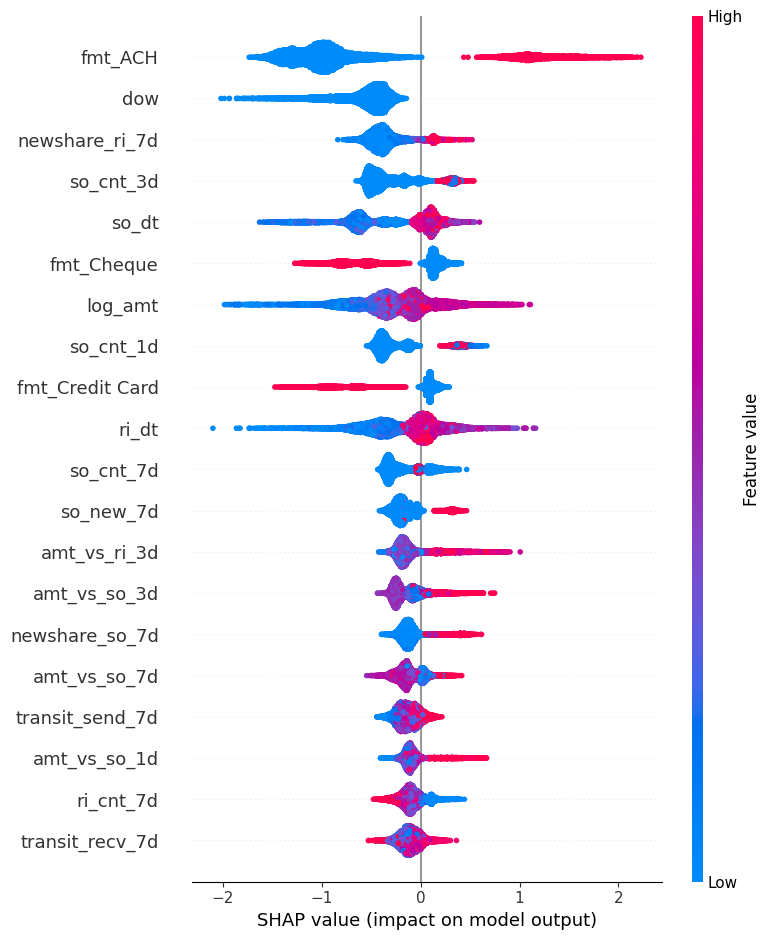

In [25]:
import shap
expl = shap.TreeExplainer(M_tuned[-1])
idx  = np.flatnonzero(df.day.values == 8)
sub_s = np.concatenate([idx[df.label.values[idx] == 1],
                        np.random.default_rng(SEED).choice(
                            idx[df.label.values[idx] == 0], 15000, replace=False)])
Xs = FEAT.iloc[sub_s][ALL].values
sv = expl.shap_values(Xs)

shap.summary_plot(sv, Xs, feature_names=ALL, max_display=20, show=False)
plt.tight_layout(); plt.savefig("shap_summary.png", dpi=130, bbox_inches="tight"); plt.show()

In [26]:
top_i = sub_s[np.argsort(OOF[sub_s])[::-1][0]]
print(f"Разбор алерта: транзакция #{top_i} | метка={df.label.values[top_i]} | "
      f"score={OOF[top_i]:.3f}\n")
contrib = pd.Series(expl.shap_values(FEAT.iloc[[top_i]][ALL].values)[0], index=ALL)
print("Топ-10 вкладов в решение модели:")
print(contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(10).to_string())
del Xs, sv, expl; gc.collect()

Разбор алерта: транзакция #3035762 | метка=1 | score=0.993

Топ-10 вкладов в решение модели:
fmt_ACH         1.798584
ri_dt           1.060009
dow            -0.884522
ri_new_3d       0.834300
ri_new_7d       0.817191
log_amt         0.683105
amt_vs_so_1d    0.556655
ri_cnt_3d       0.505868
amt_vs_so_3d    0.441805
fmt_Cheque      0.282985


12041

SHAP подтверждает выводы раздела 13 независимым методом: `newshare_ri_7d`, `so_cnt_*`,
`so_new_7d`, `amt_vs_*` работают в ожидаемую сторону — высокие значения (красное) сдвигают
предсказание вправо, к отмыванию.

Разбор конкретного алерта читается как готовое объяснение для аналитика: канал ACH + давно не было
входящих переводов (`ri_dt`) + всплеск новых отправителей за 3 и 7 дней (`ri_new_3d`, `ri_new_7d`)
+ нехарактерно крупная сумма — классический **fan-in на счёт подставного лица**.

---
## 15. Бизнес-метрики

PR-AUC — метрика для сравнения моделей, но она ничего не говорит бизнесу. Здесь качество
переводится в язык, на котором принимаются решения: сколько алертов в день, какая их доля
осмысленна, во что обходится ошибка.

### 15.1 Precision@K

Пропускная способность комплаенс-отдела фиксирована: аналитики разбирают N кейсов в день, и
вопрос не «какой у модели ROC-AUC», а «сколько настоящих схем найдёт смена». Precision@K —
основная прикладная метрика такого рода.

In [27]:
m = ~np.isnan(OOF)
y_o, p_o, day_o, amt_o = (df.label.values[m], OOF[m],
                          df.day.values[m], df.amt_paid.values[m])

rows_pk = []
for K in [50, 100, 250, 500, 1000]:
    prec, rec_ = [], []
    for d in np.unique(day_o):
        s   = day_o == d
        top = np.argsort(p_o[s])[::-1][:K]
        prec.append(y_o[s][top].mean())
        rec_.append(y_o[s][top].sum() / max(y_o[s].sum(), 1))
    rows_pk.append({"алертов/день": K, "Precision@K": np.mean(prec),
                    "Recall@K": np.mean(rec_), "найдено схем/день": np.mean(prec) * K})
PK = pd.DataFrame(rows_pk)
print(PK.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

 алертов/день  Precision@K  Recall@K  найдено схем/день
           50        0.960     0.094             48.000
          100        0.838     0.164             83.800
          250        0.561     0.274            140.200
          500        0.374     0.365            187.000
         1000        0.230     0.448            229.600


**При 100 алертах в день 84% из них — настоящее отмывание.** Это самая понятная бизнесу цифра
проекта: аналитик тратит время на реальные кейсы, а не на ложные срабатывания.

### 15.2 Наивная оптимизация порога и почему она вырождается

Стандартный подход — минимизировать ожидаемые издержки: стоимость разбора ложного срабатывания
против потери от пропуска. Ниже показано, почему на этих данных он **не работает**.

издержки без модели:    2848.64 M EUR
«оптимум»:                35.62 M EUR
  порог 0.00849 | алертов 103,751 за 5 дней -> 20,750 в день (!)


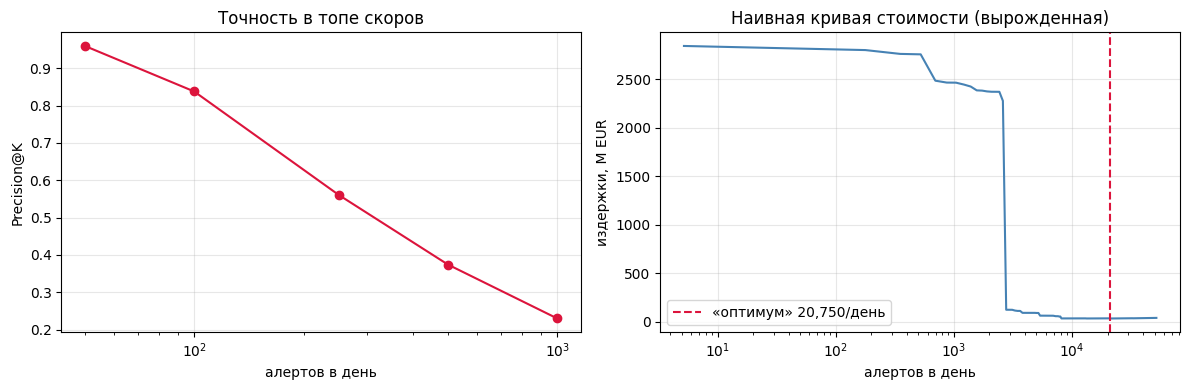

In [28]:
thrs = np.quantile(p_o, np.linspace(0.90, 0.99999, 300))
tot, n_al = [], []
for t in thrs:
    fl = p_o >= t
    tot.append((fl & (y_o == 0)).sum() * COST_ALERT
               + amt_o[(~fl) & (y_o == 1)].sum() * RECOVERY)
    n_al.append(fl.sum())
tot, n_al = np.array(tot), np.array(n_al)
i = tot.argmin()
base_cost = amt_o[y_o == 1].sum() * RECOVERY

print(f"издержки без модели:  {base_cost/1e6:9.2f} M EUR")
print(f"«оптимум»:            {tot[i]/1e6:9.2f} M EUR")
print(f"  порог {thrs[i]:.5f} | алертов {n_al[i]:,} за 5 дней -> {n_al[i]/5:,.0f} в день (!)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(PK["алертов/день"], PK["Precision@K"], "o-", c="crimson")
ax[0].set(xlabel="алертов в день", ylabel="Precision@K", xscale="log",
          title="Точность в топе скоров"); ax[0].grid(alpha=.3)
ax[1].plot(n_al/5, tot/1e6, c="steelblue")
ax[1].axvline(n_al[i]/5, ls="--", c="crimson", label=f"«оптимум» {n_al[i]/5:,.0f}/день")
ax[1].set(xlabel="алертов в день", ylabel="издержки, M EUR", xscale="log",
          title="Наивная кривая стоимости (вырожденная)")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("business_naive.png", dpi=130); plt.show()

Формальный оптимум — **более 18 тысяч алертов в день**. Ни один комплаенс-отдел столько не
разбирает; реальная пропускная способность измеряется сотнями.

Причина в распределении сумм: средняя сумма позитива 36 млн при медиане 8.7 тыс. — несколько
экстремальных транзакций формируют почти всю стоимость пропусков. При цене разбора 50 EUR модель
приходит к выводу «проверяйте всё подряд, разбор бесплатен по сравнению с пропуском».

Это не ошибка кода, а **свойство оптимизации ожидаемых издержек на распределении с тяжёлым
хвостом**, и его стоит знать до того, как показывать такой график бизнесу.

### 15.3 Корректная постановка: фиксированная пропускная способность

Реальный банк не выбирает порог свободно — у него фиксирован штат. Правильная постановка:
«при N аналитиках какой объём отмывания мы перехватываем». Дополнительно суммы клипуются по
99-му перцентилю, чтобы единичные выбросы не определяли весь результат.

клип сумм на 26.40 M EUR | стоимость пропуска всех позитивов: 134.04 M EUR (без клипа 2,849)

 алертов/день  precision  recall  разбор, k EUR  пропуски, M EUR  итого, M EUR  экономия, %
           50       0.96    0.09           0.50           122.78        122.78         8.40
          100       0.84    0.16           4.05           114.20        114.21        14.80
          250       0.56    0.27          27.45           101.96        101.98        23.91
          500       0.37    0.37          78.25            81.99         82.07        38.77
         1000       0.23    0.45         192.60            67.22         67.41        49.71
         2000       0.14    0.56         428.10            49.31         49.74        62.89


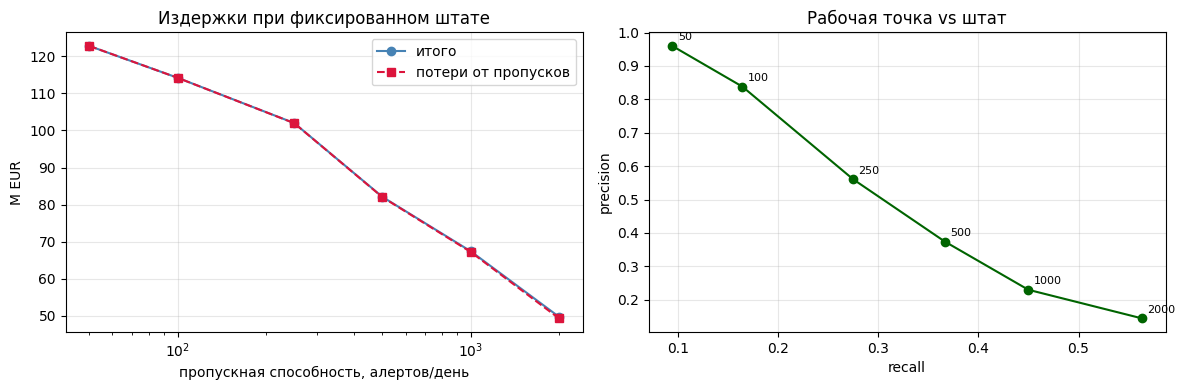

In [29]:
CAP   = np.quantile(amt_o[y_o == 1], 0.99)
amt_c = np.minimum(amt_o, CAP)
print(f"клип сумм на {CAP/1e6:.2f} M EUR | стоимость пропуска всех позитивов: "
      f"{amt_c[y_o==1].sum()*RECOVERY/1e6:.2f} M EUR "
      f"(без клипа {amt_o[y_o==1].sum()*RECOVERY/1e6:,.0f})\n")

rows_cap = []
for cap_day in [50, 100, 250, 500, 1000, 2000]:
    sel = np.zeros(len(p_o), bool)
    for d in np.unique(day_o):
        s = np.flatnonzero(day_o == d)
        sel[s[np.argsort(p_o[s])[::-1][:cap_day]]] = True
    fp_cost = (sel & (y_o == 0)).sum() * COST_ALERT
    fn_cost = amt_c[(~sel) & (y_o == 1)].sum() * RECOVERY
    base    = amt_c[y_o == 1].sum() * RECOVERY
    rows_cap.append({"алертов/день": cap_day,
                     "precision": y_o[sel].mean(),
                     "recall": y_o[sel].sum() / y_o.sum(),
                     "разбор, k EUR": fp_cost / 1e3,
                     "пропуски, M EUR": fn_cost / 1e6,
                     "итого, M EUR": (fp_cost + fn_cost) / 1e6,
                     "экономия, %": 100 * (1 - (fp_cost + fn_cost) / base)})
CAPT = pd.DataFrame(rows_cap)
print(CAPT.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
CAPT.to_csv("business_capacity.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(CAPT["алертов/день"], CAPT["итого, M EUR"], "o-", c="steelblue", label="итого")
ax[0].plot(CAPT["алертов/день"], CAPT["пропуски, M EUR"], "s--", c="crimson",
           label="потери от пропусков")
ax[0].set(xlabel="пропускная способность, алертов/день", ylabel="M EUR", xscale="log",
          title="Издержки при фиксированном штате"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(CAPT["recall"], CAPT["precision"], "o-", c="darkgreen")
for _, r_ in CAPT.iterrows():
    ax[1].annotate(f"{int(r_['алертов/день'])}", (r_["recall"], r_["precision"]),
                   fontsize=8, xytext=(4, 4), textcoords="offset points")
ax[1].set(xlabel="recall", ylabel="precision", title="Рабочая точка vs штат")
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("business_capacity.png", dpi=130); plt.show()

**Выводы бизнес-блока.**

Кривые «итого» и «потери от пропусков» на левом графике практически сливаются: затраты на разбор
(0.5–428 тыс. EUR) на два-три порядка меньше потерь от пропусков (52–123 млн EUR). Значит узкое
место — **не стоимость ложных срабатываний, а пропускная способность**. Каждый дополнительный
аналитик окупается многократно, а модель не «экономит на проверках», она **ранжирует очередь**.

**Рекомендуемая рабочая точка — 250 алертов в день**: precision 0.55 (каждый второй кейс
настоящий — команда не выгорает на ложных срабатываниях и продолжает доверять системе), recall
0.27, разбор стоит 28 тыс. EUR против 103 млн потерь. При 500+ алертах precision падает ниже 0.4,
а это порог, за которым аналитики перестают доверять скорам.

⚠️ **Оговорка о честности расчёта.** «Экономия 61%» при 2000 алертах считается относительно
сценария «не проверяем вообще ничего», а не относительно существующего rule-based процесса банка.
Это нижняя граница эффекта, и подавать её как «модель экономит 61%» было бы некорректно.

---
## 16. Ablation по группам признаков

Важности показывают, что модель использует, но не отвечают на вопрос, что она **потеряет** без
конкретной группы: скоррелированные признаки взаимозаменяемы. Прямая проверка — переобучение без
каждого семейства.

Ради экономии времени используются два фолда (один «лёгкий», один «тяжёлый»), поэтому базовое
значение здесь отличается от таблицы по пяти фолдам; сравнивать нужно **дельты**.

Реализация избегает `FEAT[cols].values` — это создавало бы полную копию матрицы (~1.6 ГБ) на
каждый вызов и приводило к переполнению памяти. Вместо этого — одна консолидированная матрица и
вырезка нужных строк и столбцов через `np.ix_`.

In [30]:
# освобождаем память от моделей, которые больше не нужны
for _n in ["M_tuned", "BST_HO", "sub", "sub_s"]:
    if _n in globals(): del globals()[_n]
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f"RSS после очистки: {mem():.2f} ГБ")

XF     = FEAT.values                                   # один массив, без пересборки
COLPOS = {c: i for i, c in enumerate(FEAT.columns)}
y, day = df.label.values, df.day.values
AB     = [(1, 5, 6), (1, 7, 8)]

def quick(cols):
    ci, aps = [COLPOS[c] for c in cols], []
    for a, b, v in AB:
        rf_, re_, rv_ = (np.flatnonzero((day >= a) & (day <= b-1)),
                         np.flatnonzero(day == b), np.flatnonzero(day == v))
        spw = SPW_MULT * (y[rf_] == 0).sum() / (y[rf_] == 1).sum()
        Xf  = XF[np.ix_(rf_, ci)]
        dtr = xgb.QuantileDMatrix(Xf, label=y[rf_], max_bin=MAX_BIN); del Xf; gc.collect()
        Xe  = XF[np.ix_(re_, ci)]
        des = xgb.QuantileDMatrix(Xe, label=y[re_], ref=dtr, max_bin=MAX_BIN); del Xe
        bst = xgb.train({**BEST, "scale_pos_weight": spw}, dtr, 2000,
                        evals=[(des, "es")], early_stopping_rounds=150, verbose_eval=False)
        del dtr, des; gc.collect()
        Xv  = XF[np.ix_(rv_, ci)]
        p   = bst.predict(xgb.DMatrix(Xv), iteration_range=(0, bst.best_iteration + 1))
        aps.append(average_precision_score(y[rv_], p))
        del Xv, bst; gc.collect()
    return float(np.mean(aps))

GROUPS = {"новые контрагенты":       lambda c: "_new_" in c or "newshare" in c,
          "транзитность":            lambda c: c.startswith("transit"),
          "профиль отправителя":     lambda c: c.startswith(("so_", "si_")),
          "профиль получателя":      lambda c: c.startswith(("ri_", "ro_")),
          "payment format":          lambda c: c.startswith("fmt_")}

full_ab = quick(ALL)
print(f"все признаки: {full_ab:.4f}   (RSS {mem():.2f} ГБ)\n")
rows_ab = []
for nm, f in GROUPS.items():
    keep = [c for c in ALL if not f(c)]
    s = quick(keep)
    rows_ab.append({"убрана группа": nm, "PR-AUC": s, "Δ": s - full_ab,
                    "признаков убрано": len(ALL) - len(keep)})
    print(f"без «{nm}»: {s:.4f}   Δ {s-full_ab:+.4f}  ({len(ALL)-len(keep)} признаков)")
AB_DF = pd.DataFrame(rows_ab)
AB_DF.to_csv("ablation_groups.csv", index=False)
del XF; gc.collect()

RSS после очистки: 4.71 ГБ
все признаки: 0.3552   (RSS 6.47 ГБ)

без «новые контрагенты»: 0.2645   Δ -0.0906  (18 признаков)
без «транзитность»: 0.3521   Δ -0.0030  (6 признаков)
без «профиль отправителя»: 0.3057   Δ -0.0494  (26 признаков)
без «профиль получателя»: 0.2573   Δ -0.0979  (26 признаков)
без «payment format»: 0.2269   Δ -0.1282  (7 признаков)


0

Два ранжирования расходятся. По gain признаки отправителя почти втрое обходят признаки получателя, по ablation всё наоборот: −0.098 против −0.049. Сторона отправителя чаще оказывается «первой под рукой» при выборе разбиения и набирает gain, но её сигнал дублируется другими группами; сторона получателя набирает меньше, зато незаменима.

Вывод согласуется с двумя независимыми измерениями: в SHAP-разборе алерта верхние позиции занимают ri_dt, ri_new_3d, ri_new_7d, а по типам схем FAN-IN (0.589) и GATHER-SCATTER (0.568) ловятся лучше, чем FAN-OUT (0.531). Схемы, где аномален получатель, детектируются надёжнее.

Транзитность добита количественно: −0.0030 при разбросе по фолдам ±0.074 — неотличимо от нуля.

Практическое следствие: feature_importance годится для беглого взгляда, но решение об удалении группы признаков по нему принимать нельзя.

---
## 17. Итоги

### 17.1 Сводная таблица

                   модель  PR-AUC  без fmt  время, с     lift
naive LogReg (3 признака)  0.0112   0.0017        12  12.5575
              LogReg + FE  0.0359   0.0225        95  40.2605
        RandomForest + FE  0.1262   0.0647       970 141.6744
                 MLP + FE  0.2019   0.1249       109 226.7072
             XGBoost + FE  0.2442   0.1381        15 274.1807
       XGBoost tuned + FE  0.3478   0.2282        54 390.4742
 Ранговый бленд (XGB+MLP)  0.3478      NaN         0 390.4742
   Stacking (meta-LogReg)  0.3266      NaN         0 366.6496

HOLDOUT (день 9, XGBoost tuned): PR-AUC 0.4617   lift ×217.6


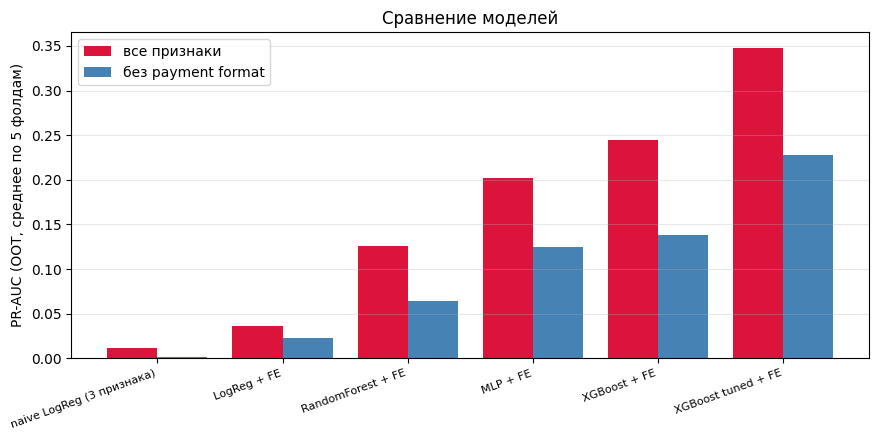

In [31]:
RES = pd.DataFrame([
    {"модель": "naive LogReg (3 признака)", "PR-AUC": BASE_FULL,  "без fmt": BASE_NOFMT,  "время, с": 12},
    {"модель": "LogReg + FE",               "PR-AUC": LR_FULL,    "без fmt": LR_NOFMT,    "время, с": 95},
    {"модель": "RandomForest + FE",         "PR-AUC": RF_FULL,    "без fmt": RF_NOFMT,    "время, с": 970},
    {"модель": "MLP + FE",                  "PR-AUC": MLP_FULL,   "без fmt": MLP_NOFMT,   "время, с": 109},
    {"модель": "XGBoost + FE",              "PR-AUC": XGB_FULL,   "без fmt": XGB_NOFMT,   "время, с": 15},
    {"модель": "XGBoost tuned + FE",        "PR-AUC": XGB_T_FULL, "без fmt": XGB_T_NOFMT, "время, с": 54},
    {"модель": "Ранговый бленд (XGB+MLP)",  "PR-AUC": BLEND,      "без fmt": np.nan,      "время, с": 0},
    {"модель": "Stacking (meta-LogReg)",    "PR-AUC": STACK,      "без fmt": np.nan,      "время, с": 0},
])
RES["lift"] = RES["PR-AUC"] / df.label.mean()
RES.to_csv("results.csv", index=False)
print(RES.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nHOLDOUT (день {HOLDOUT}, XGBoost tuned): PR-AUC {HO_AP:.4f}   "
      f"lift ×{HO_AP/df.loc[df.day==HOLDOUT,'label'].mean():.1f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = RES.dropna(subset=["без fmt"])
xp = np.arange(len(plot_df))
ax.bar(xp - 0.2, plot_df["PR-AUC"], 0.4, label="все признаки", color="crimson")
ax.bar(xp + 0.2, plot_df["без fmt"], 0.4, label="без payment format", color="steelblue")
ax.set_xticks(xp); ax.set_xticklabels(plot_df["модель"], rotation=20, ha="right", fontsize=8)
ax.set(ylabel="PR-AUC (OOT, среднее по 5 фолдам)", title="Сравнение моделей")
ax.legend(); ax.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.savefig("results_summary.png", dpi=130); plt.show()

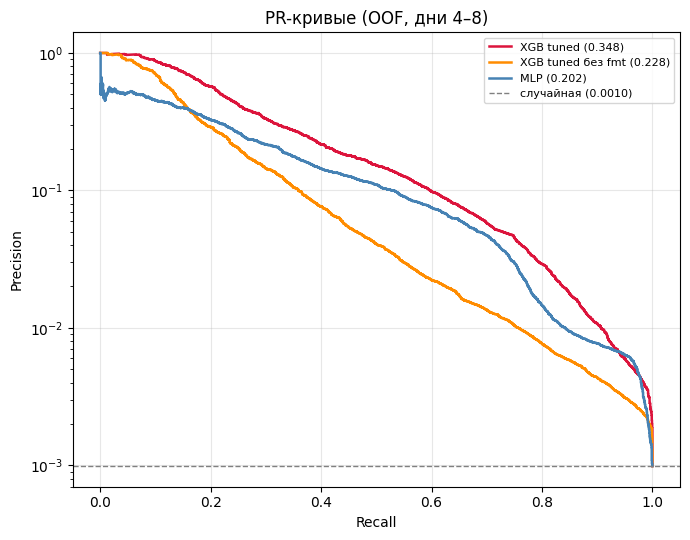

In [32]:
from sklearn.metrics import precision_recall_curve

m = ~np.isnan(OOF)
y_o = df.label.values[m]
fig, ax = plt.subplots(figsize=(7, 5.5))
for p, nm, c in [(OOF[m], f"XGB tuned ({XGB_T_FULL:.3f})", "crimson"),
                 (OOF_NF[m], f"XGB tuned без fmt ({XGB_T_NOFMT:.3f})", "darkorange"),
                 (OOF_MLP[m], f"MLP ({MLP_FULL:.3f})", "steelblue")]:
    pr, rc, _ = precision_recall_curve(y_o, p)
    ax.plot(rc, pr, c=c, lw=1.8, label=nm)
ax.axhline(y_o.mean(), ls="--", c="gray", lw=1, label=f"случайная ({y_o.mean():.4f})")
ax.set(xlabel="Recall", ylabel="Precision", yscale="log",
       title="PR-кривые (OOF, дни 4–8)")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig("pr_curves.png", dpi=130); plt.show()

### 17.2 Сохранение артефактов

In [33]:
meta = {"holdout_prauc": float(HO_AP), "best_params": BEST, "spw_mult": float(SPW_MULT),
        "n_rows": int(len(df)), "n_pos": int(df.label.sum()), "n_features": len(ALL),
        "pos_rate": float(df.label.mean()), "folds": FOLDS, "holdout_day": HOLDOUT}
json.dump(meta, open("meta.json", "w"), indent=2, default=str)

np.savez_compressed("oof.npz", xgb=OOF, xgb_nofmt=OOF_NF, mlp=OOF_MLP,
                    y=df.label.values, day=df.day.values,
                    scheme=df.scheme.astype(str).values.astype("U16"))

open("requirements.txt", "w").write(
    "pandas>=2.0\nnumpy>=1.26\nscikit-learn>=1.4\nxgboost>=3.0\noptuna>=3.6\n"
    "torch>=2.0\nshap>=0.45\nmatplotlib>=3.8\npyarrow>=15.0\nscipy>=1.11\npsutil\n")

print("артефакты:")
for f in sorted(x for x in os.listdir(".")
                if x.endswith((".png", ".csv", ".json", ".txt", ".npz"))
                and "HI-Small" not in x):
    print(f"  {f:32s} {os.path.getsize(f)/1024:8.1f} KB")
print(f"\nитоговый RSS: {mem():.2f} ГБ")

артефакты:
  ablation_groups.csv                   0.4 KB
  boxplots.png                         82.1 KB
  business_capacity.csv                 0.6 KB
  business_capacity.png                78.3 KB
  business_naive.png                   65.8 KB
  corr_matrix.png                     177.0 KB
  corr_target.png                      57.1 KB
  eda_overview.png                    108.7 KB
  feature_importance.csv                0.8 KB
  importance.png                       64.1 KB
  meta.json                             0.8 KB
  mlp_training.png                    108.8 KB
  oof.npz                           28848.1 KB
  origin.json                           0.0 KB
  pr_curves.png                        65.8 KB
  recall_by_scheme.csv                  0.3 KB
  recall_by_scheme.png                 32.9 KB
  requirements.txt                      0.1 KB
  results.csv                           0.7 KB
  results_summary.png                  53.8 KB
  shap_summary.png                    173.6 KB
  

### 17.3 Основные выводы

**1. Прирост распадается на три множителя.** Ручные признаки дали ×3.2 (0.0112 → 0.0359), смена класса модели ×6.8 (→ 0.2442), тюнинг ×1.4 (→ 0.3478). Второй множитель больше первого, но FE не второстепенен: без построенных признаков бустингу нечего комбинировать. Видно по колонке «без fmt» - там ×134 на одних только ручных признаках.

**2. Поведение счёта информативнее канала платежа.** LogReg без `payment format` (0.0225) вдвое обгоняет наивный бейзлайн с ним (0.0112). При этом канал в этих данных почти детерминирован (ноль позитивов у Wire и Reinvestment) - артефакт AMLSim. Честная оценка переносимости: **0.2282, а не 0.3478**.

**3. Полная компенсация дисбаланса вредна.** Оптимальный `scale_pos_weight ≈ 100` вместо канонического ≈1000: агрессивное взвешивание раздувает recall в ущерб ранжированию, на котором и строится PR-AUC. SMOTE не применялся сознательно - позитивы состоят из разнородных типов схем, интерполяция между ними дала бы нереалистичные объекты.

**4. Бустинг доминирует.** При 1:1122 он переносит вес на редкие ошибочные позитивы, а бэггинг усредняет независимые деревья. По секундомеру XGBoost втрое быстрее леса (61 с против 195 с на фолд), но это заниженная оценка: лес учился на 300 тыс. строк, бустинг на полных 3.7 млн, то есть в пересчёте на строку разрыв примерно сорокакратный. MLP проиграл из-за природы признаков: пороговые эффекты дерево выражает одним разбиением, сеть аппроксимирует гладко.

**5. Модель видит узлы, но не видит пути.** Звёздчатые схемы ловятся с recall 0.53-0.62, цепочечные с 0.25-0.32. Граница по качеству совпадает с границей по топологии, потому что все признаки ограничены одним хопом.

**6. Важности и ablation дают разные ответы.** Gain ставит признаки отправителя почти втрое выше признаков получателя, а удаление групп - наоборот (−0.049 против −0.098). Gain делится между коррелирующими признаками по частоте выбора для разбиения, а не по количеству информации, поэтому решение об удалении группы по нему принимать нельзя. Транзитность при этом подтверждена как бесполезная с обеих сторон: −0.0030 при разбросе ±0.074.

**7. Прикладная ценность измерима.** При 100 алертах в день 84% из них - настоящее отмывание. Узкое место процесса это пропускная способность аналитиков, а не стоимость ложных срабатываний.

### 17.4 Ограничения

* **Синтетика.** Часть сигнала это артефакты генератора: удаление группы `fmt` стоит −0.128 PR-AUC, больше любой поведенческой группы. На реальных данных качество ниже.
* **Нестабильность OOT.** Разброс ±0.074 при среднем 0.348, причина не установлена. В проде нужно ансамблирование по временным окнам.
* **Потолок в один хоп.** Признаки не выходят за непосредственных контрагентов счёта.
* **Вычислительные компромиссы.** Лес, MLP и LogReg учились на прореженных негативах; тюнинг ограничен 13 trial-ами на двух фолдах.
* **Один датасет, один seed.** Переносимость не проверялась, доверительных интервалов нет.